In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Phishing_Project/datasets/CEAS_08.csv')
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
df.shape

(39154, 7)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [ ]:
df.isnull().sum()

,0
sender,0
receiver,462
date,0
subject,28
body,0
label,0
urls,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(39154, 7)

In [ ]:
df = df.drop("receiver", axis='columns')

In [ ]:
df = df.dropna(subset=['sender'])

In [ ]:
df = df.dropna(subset=['date'])

In [ ]:
df['subject'] = df['subject'].fillna('No Subject')

In [ ]:
df.shape

(39154, 6)

In [ ]:
df.head()

,sender,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
df['label'].value_counts()


,count
label,
1,21842
0,17312


In [ ]:
df['sender'] = df['sender'].astype(str)
df['subject'] = df['subject'].astype(str)
df['date'] = df['date'].astype(str)

In [ ]:
df['sender'] = df['sender'].str.strip()
df['subject'] = df['subject'].str.strip()
df['date'] = df['date'].str.strip()

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

In [ ]:
df = df.dropna(subset=['date'])

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.info()
df.isnull().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39139 entries, 0 to 39138
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   sender   39139 non-null  object             
 1   date     39139 non-null  datetime64[ns, UTC]
 2   subject  39139 non-null  object             
 3   body     39139 non-null  object             
 4   label    39139 non-null  int64              
 5   urls     39139 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(2), object(3)
memory usage: 1.8+ MB


,sender,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,2008-08-05 23:31:02+00:00,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,2008-08-05 23:31:03+00:00,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,2008-08-06 08:28:00+00:00,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,2008-08-05 23:31:20+00:00,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,2008-08-05 23:31:21+00:00,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


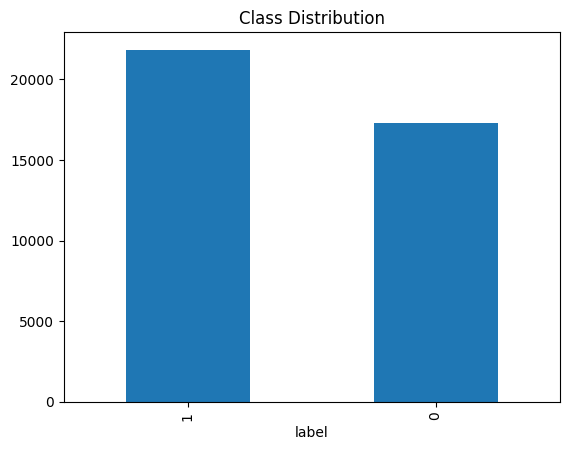

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [ ]:
import os

output_dir = '/content/drive/MyDrive/Phishing_Project/cleaned_data'
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, 'cleaned_email_metadata.csv'), index=False)

In [ ]:
# ATTACHMENT DETECTION BEFORE PREPROCESSING

import re
import pandas as pd

# COMMON ATTACHMENT EXTENSIONS

attachment_extensions = [
    '.pdf', '.doc', '.docx', '.xls', '.xlsx',
    '.ppt', '.pptx', '.zip', '.rar',
    '.exe', '.scr', '.js', '.bat',
    '.csv', '.txt', '.rtf',
    '.7z', '.iso', '.apk',
    '.docm', '.xlsm'
]

# FUNCTION TO DETECT ATTACHMENTS

def detect_attachments(body):

    body = str(body).lower()

    found_attachments = []

    for ext in attachment_extensions:

        # regex to detect filenames like invoice.pdf
        pattern = r'\b[\w\-\_]+\{}\\b'.format(re.escape(ext))

        matches = re.findall(pattern, body)

        if matches:
            found_attachments.extend(matches)

    return found_attachments

# APPLY ON TEXT COLUMN

df['attachment_names'] = df['body'].apply(detect_attachments)

# FLAG IF ATTACHMENT EXISTS

df['has_attachment'] = df['attachment_names'].apply(
    lambda x: 1 if len(x) > 0 else 0
)

# COUNT NUMBER OF ATTACHMENTS

df['attachment_count'] = df['attachment_names'].apply(len)


print(df[['body', 'attachment_names', 'has_attachment', 'attachment_count']].head())

                                                body attachment_names  \
0  Buck up, your troubles caused by small dimensi...               []   
1  \nUpgrade your sex and pleasures with these te...               []   
2  >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...               []   
3  Would anyone object to removing .so from this ...               []   
4  \nWelcomeFastShippingCustomerSupport\nhttp://7...               []   

   has_attachment  attachment_count  
0               0                 0  
1               0                 0  
2               0                 0  
3               0                 0  
4               0                 0  


In [ ]:
df_meta = df.copy()

In [ ]:
import re

# extract email
df_meta['sender_email'] = df_meta['sender'].str.extract(r'<(.*?)>')
df_meta['sender_email'] = df_meta['sender_email'].fillna(df_meta['sender'])

# username & domain
df_meta['sender_username'] = df_meta['sender_email'].apply(
    lambda x: x.split('@')[0] if '@' in str(x) else ''
)

df_meta['sender_domain'] = df_meta['sender_email'].apply(
    lambda x: x.split('@')[1] if '@' in str(x) else ''
)

# display name
df_meta['sender_name'] = df_meta['sender'].str.extract(r'^(.*?)<')
df_meta['sender_name'] = df_meta['sender_name'].fillna('').str.strip()

In [ ]:
# length
df_meta['sender_email_length'] = df_meta['sender_email'].apply(len)

# numbers in username
df_meta['sender_has_numbers'] = df_meta['sender_username'].apply(
    lambda x: int(any(c.isdigit() for c in str(x)))
)

# special characters
df_meta['sender_special_char_count'] = df_meta['sender_username'].apply(
    lambda x: len(re.findall(r'[^a-zA-Z0-9]', str(x)))
)

# uppercase ratio
df_meta['sender_uppercase_ratio'] = df_meta['sender_email'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

In [ ]:
def sender_mismatch(row):
    name = str(row['sender_name']).lower()
    username = str(row['sender_username']).lower()

    name_tokens = set(re.findall(r'[a-z]+', name))
    user_tokens = set(re.findall(r'[a-z]+', username))

    return int(len(name_tokens.intersection(user_tokens)) == 0)

df_meta['sender_name_email_mismatch'] = df_meta.apply(sender_mismatch, axis=1)

In [ ]:
df_meta['subject'] = df_meta['subject'].fillna('No Subject')

In [ ]:
df_meta['subject_length'] = df_meta['subject'].apply(len)

df_meta['subject_word_count'] = df_meta['subject'].apply(
    lambda x: len(str(x).split())
)

df_meta['subject_uppercase_ratio'] = df_meta['subject'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)),1)
)

df_meta['subject_exclamation_count'] = df_meta['subject'].apply(
    lambda x: str(x).count('!')
)

df_meta['subject_special_char_count'] = df_meta['subject'].apply(
    lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', str(x)))
)

df_meta['subject_has_reply_forward'] = df_meta['subject'].apply(
    lambda x: int(str(x).lower().startswith(('re:', 'fwd:')))
)

In [ ]:
import re
import math
from collections import Counter

# entropy
def text_entropy(text):

    text = str(text)

    freq = Counter(text)

    probs = [v / len(text) for v in freq.values()]

    return -sum(p * math.log2(p) for p in probs)

# suspicious score
def subject_suspicious_score(subject):

    subject = str(subject)

    score = 0

    uppercase_ratio = sum(c.isupper() for c in subject) / max(len(subject), 1)

    punct_count = len(re.findall(r'[!@#$%^&*()_+=]', subject))

    digit_ratio = sum(c.isdigit() for c in subject) / max(len(subject), 1)

    if uppercase_ratio > 0.3:
        score += 1

    if punct_count > 2:
        score += 1

    if digit_ratio > 0.2:
        score += 1

    if re.search(r'(.)\1{3,}', subject):
        score += 1

    return score

# apply features
df_meta['subject_entropy'] = df_meta['subject'].apply(text_entropy)

df_meta['subject_suspicious_score'] = df_meta['subject'].apply(
    subject_suspicious_score
)

In [ ]:
import pandas as pd

df_meta['date'] = pd.to_datetime(df_meta['date'], errors='coerce')

In [ ]:
df_meta['email_hour'] = df_meta['date'].dt.hour
df_meta['email_day'] = df_meta['date'].dt.day_name()
df_meta['email_month'] = df_meta['date'].dt.month

df_meta['is_weekend'] = df_meta['date'].dt.weekday.apply(lambda x: int(x >= 5))

df_meta['is_night_email'] = df_meta['email_hour'].apply(lambda x: int(0 <= x <= 5))

In [ ]:
sender_freq = df_meta['sender_email'].value_counts()

df_meta['sender_frequency'] = df_meta['sender_email'].map(sender_freq)

In [ ]:
df_meta['domain_length'] = df_meta['sender_domain'].apply(len)

df_meta['domain_has_hyphen'] = df_meta['sender_domain'].apply(
    lambda x: int('-' in str(x))
)

df_meta['subdomain_count'] = df_meta['sender_domain'].apply(
    lambda x: str(x).count('.')
)

In [ ]:
df_meta['domain_tld'] = df_meta['sender_domain'].apply(
    lambda x: str(x).split('.')[-1]
)

suspicious_tlds = ['xyz','top','club','buzz','ru','tk']

df_meta['suspicious_tld'] = df_meta['domain_tld'].apply(
    lambda x: int(x in suspicious_tlds)
)

In [ ]:
free_providers = ['gmail.com','yahoo.com','hotmail.com','outlook.com']

df_meta['is_free_provider'] = df_meta['sender_domain'].apply(
    lambda x: int(x in free_providers)
)

In [ ]:
df_meta['sender_domain'] = df_meta['sender_domain'].str.lower().str.strip()

In [ ]:
df_meta['subject'] = df_meta['subject'].str.strip()

In [ ]:
email_pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'

df_meta['valid_sender_email'] = df_meta['sender_email'].apply(
    lambda x: int(bool(re.match(email_pattern, str(x))))
)

In [ ]:
domain_freq = df_meta['sender_domain'].value_counts()

df_meta['domain_frequency'] = df_meta['sender_domain'].map(domain_freq)

In [ ]:
subject_freq = df_meta['subject'].value_counts()

df_meta['subject_frequency'] = df_meta['subject'].map(subject_freq)

In [ ]:
df_meta['has_empty_subject'] = df_meta['subject'].apply(
    lambda x: int(str(x).strip() == '' or str(x).lower() == 'no subject')
)

In [ ]:
df_meta['timezone'] = df['date'].astype(str).str.extract(r'([+-]\d{4})')

In [ ]:
df_meta['subject_url_count'] = df_meta['subject'].apply(
    lambda x: len(re.findall(r'http[s]?://|www\.', str(x).lower()))
)

In [ ]:
df_meta['subject_unique_char_ratio'] = df_meta['subject'].apply(
    lambda x: len(set(str(x))) / max(len(str(x)),1)
)

In [ ]:
df_meta['subject_length'] = df_meta['subject_length'].clip(upper=300)

df_meta['sender_email_length'] = df_meta['sender_email_length'].clip(upper=100)

In [ ]:
df_meta = df_meta.drop(columns=[
    'sender',
    'sender_email',
    'sender_username',
    'sender_name',
    'subject',
    'date',
    'domain_tld'
])

In [ ]:
df_meta.head()
df_meta.info()
df_meta.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39139 entries, 0 to 39138
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   body                        39139 non-null  object 
 1   label                       39139 non-null  int64  
 2   urls                        39139 non-null  int64  
 3   attachment_names            39139 non-null  object 
 4   has_attachment              39139 non-null  int64  
 5   attachment_count            39139 non-null  int64  
 6   sender_domain               39139 non-null  object 
 7   sender_email_length         39139 non-null  int64  
 8   sender_has_numbers          39139 non-null  int64  
 9   sender_special_char_count   39139 non-null  int64  
 10  sender_uppercase_ratio      39139 non-null  float64
 11  sender_name_email_mismatch  39139 non-null  int64  
 12  subject_length              39139 non-null  int64  
 13  subject_word_count          391

(39139, 38)

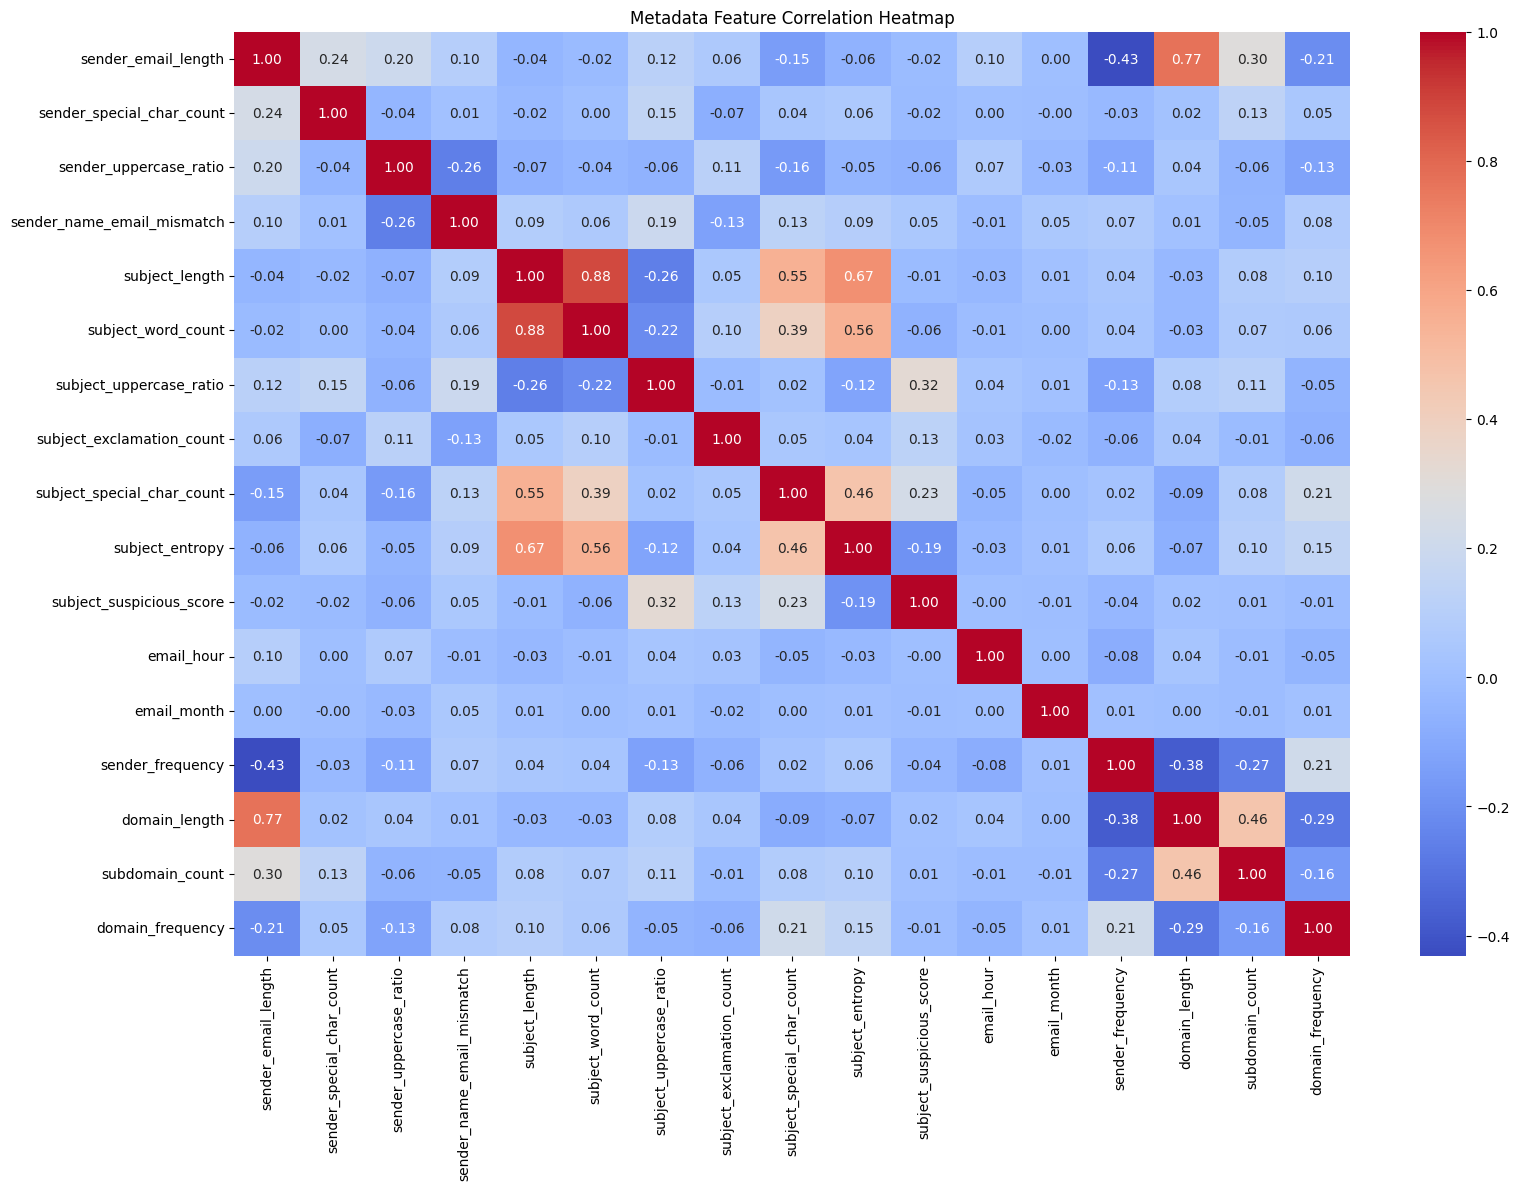

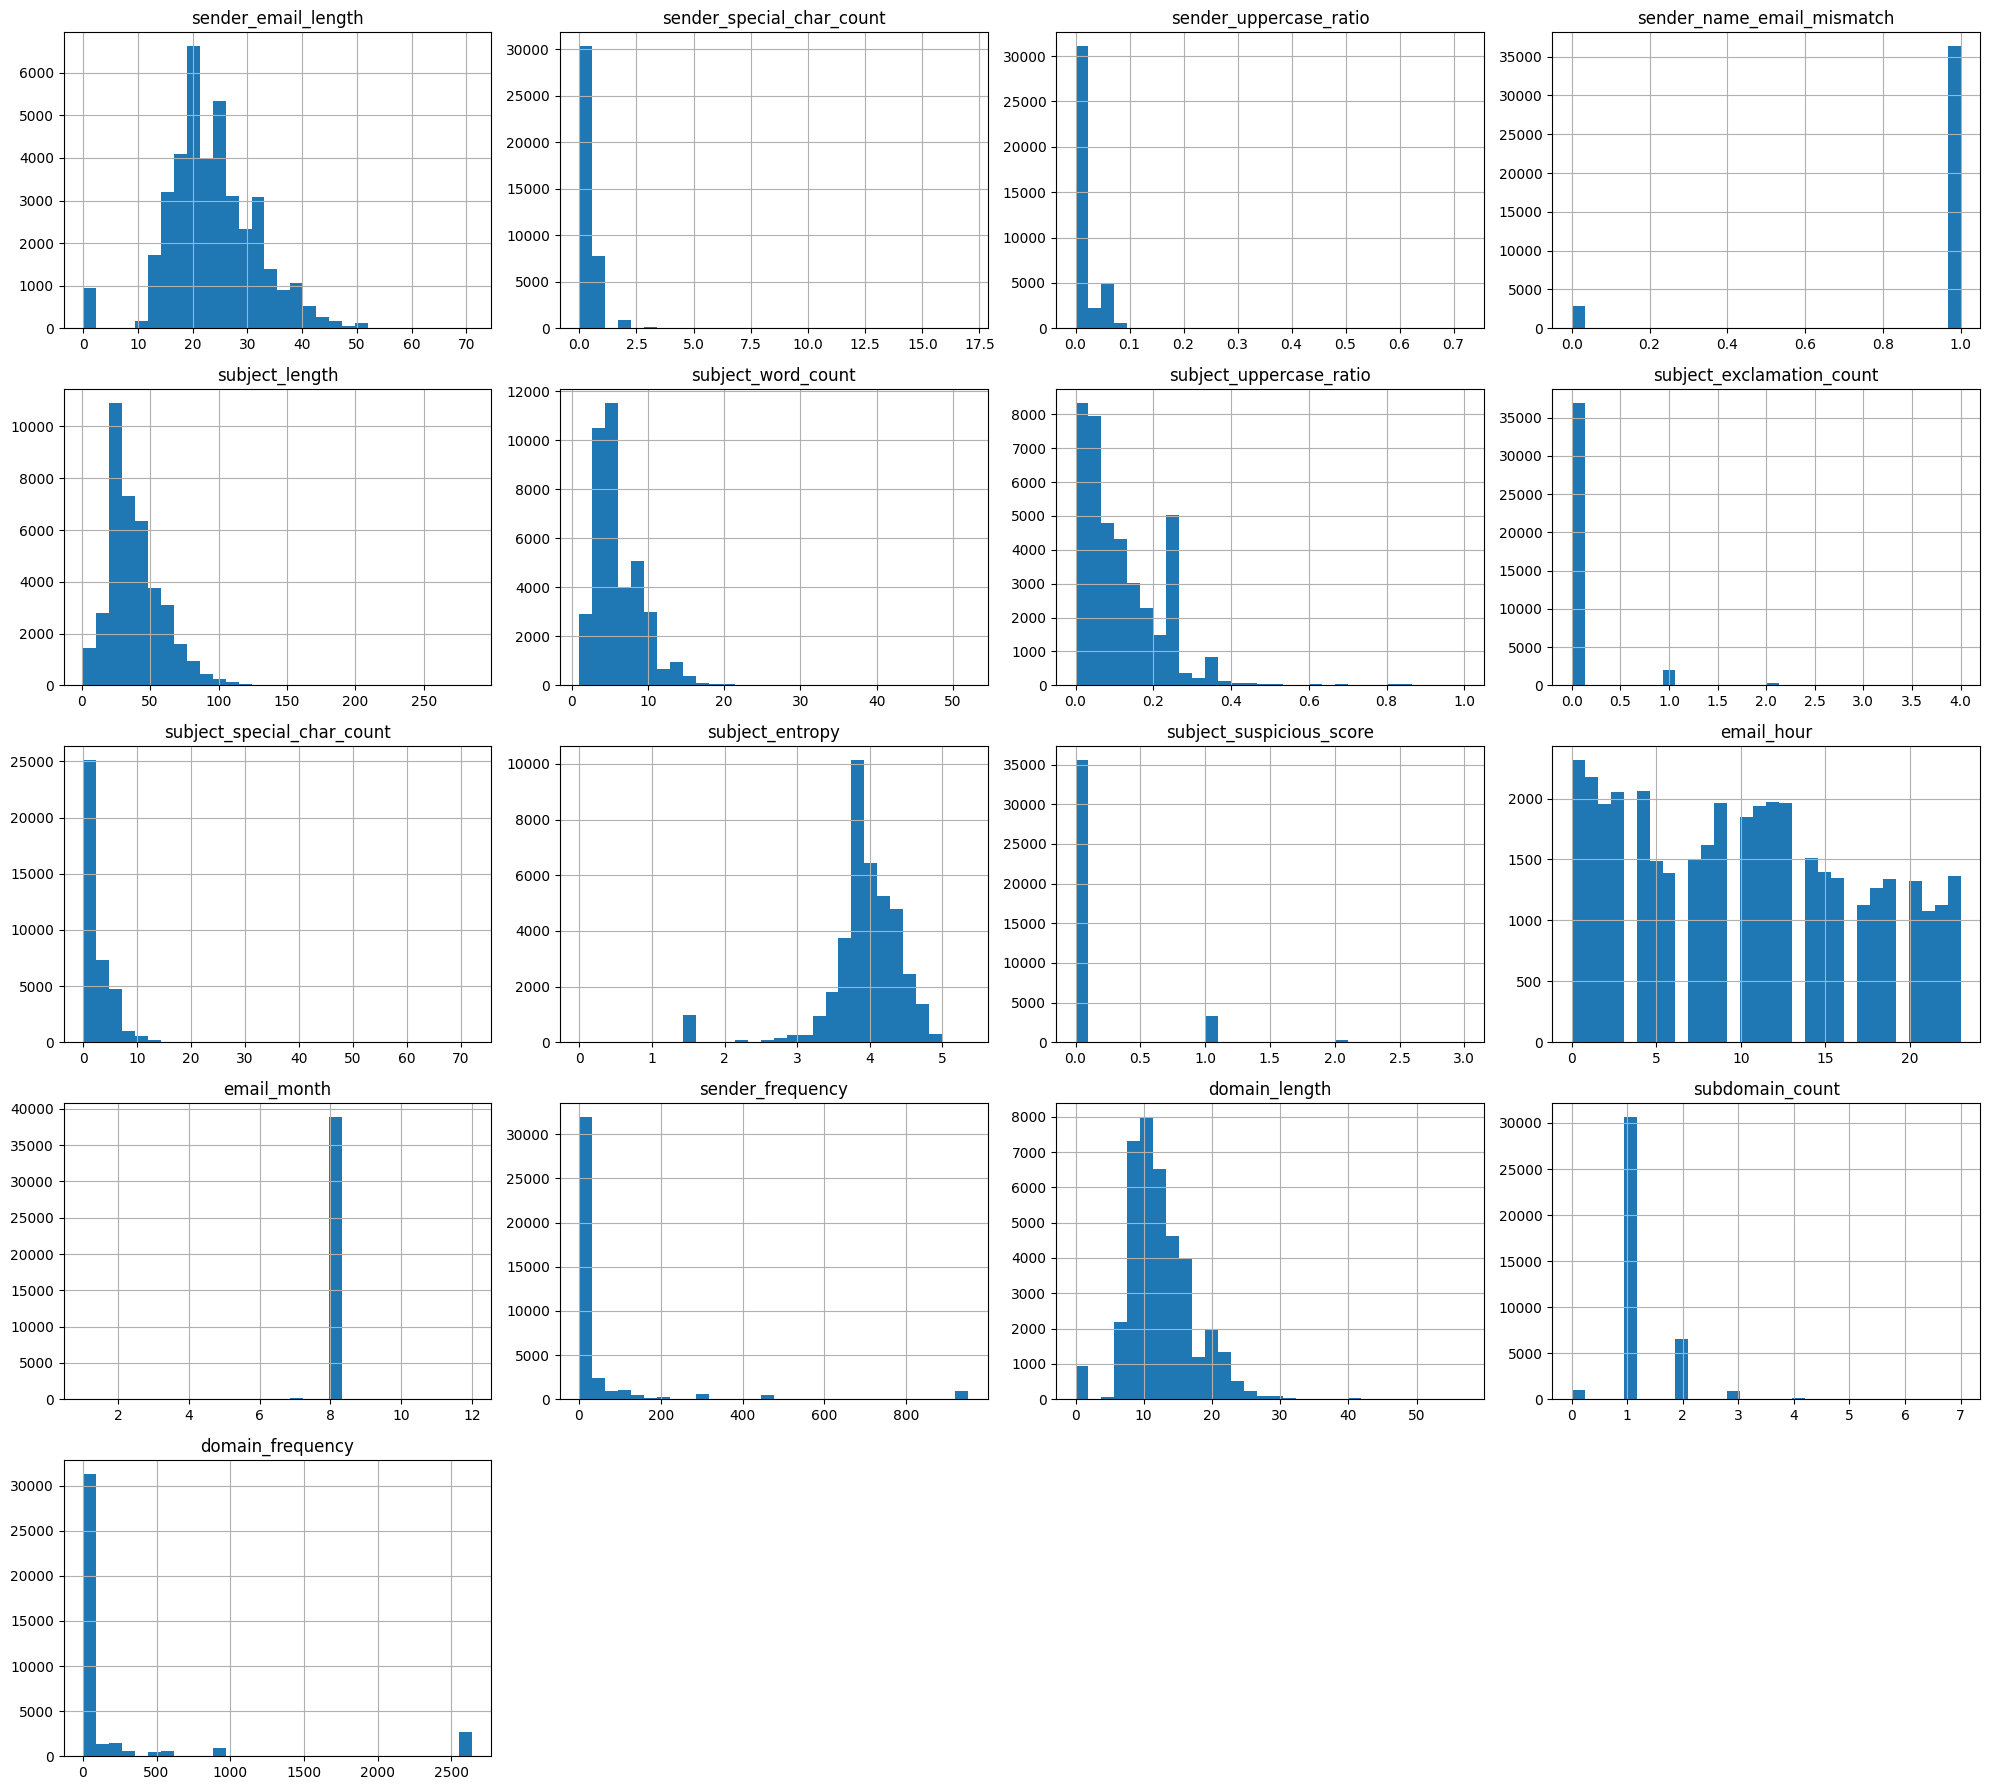

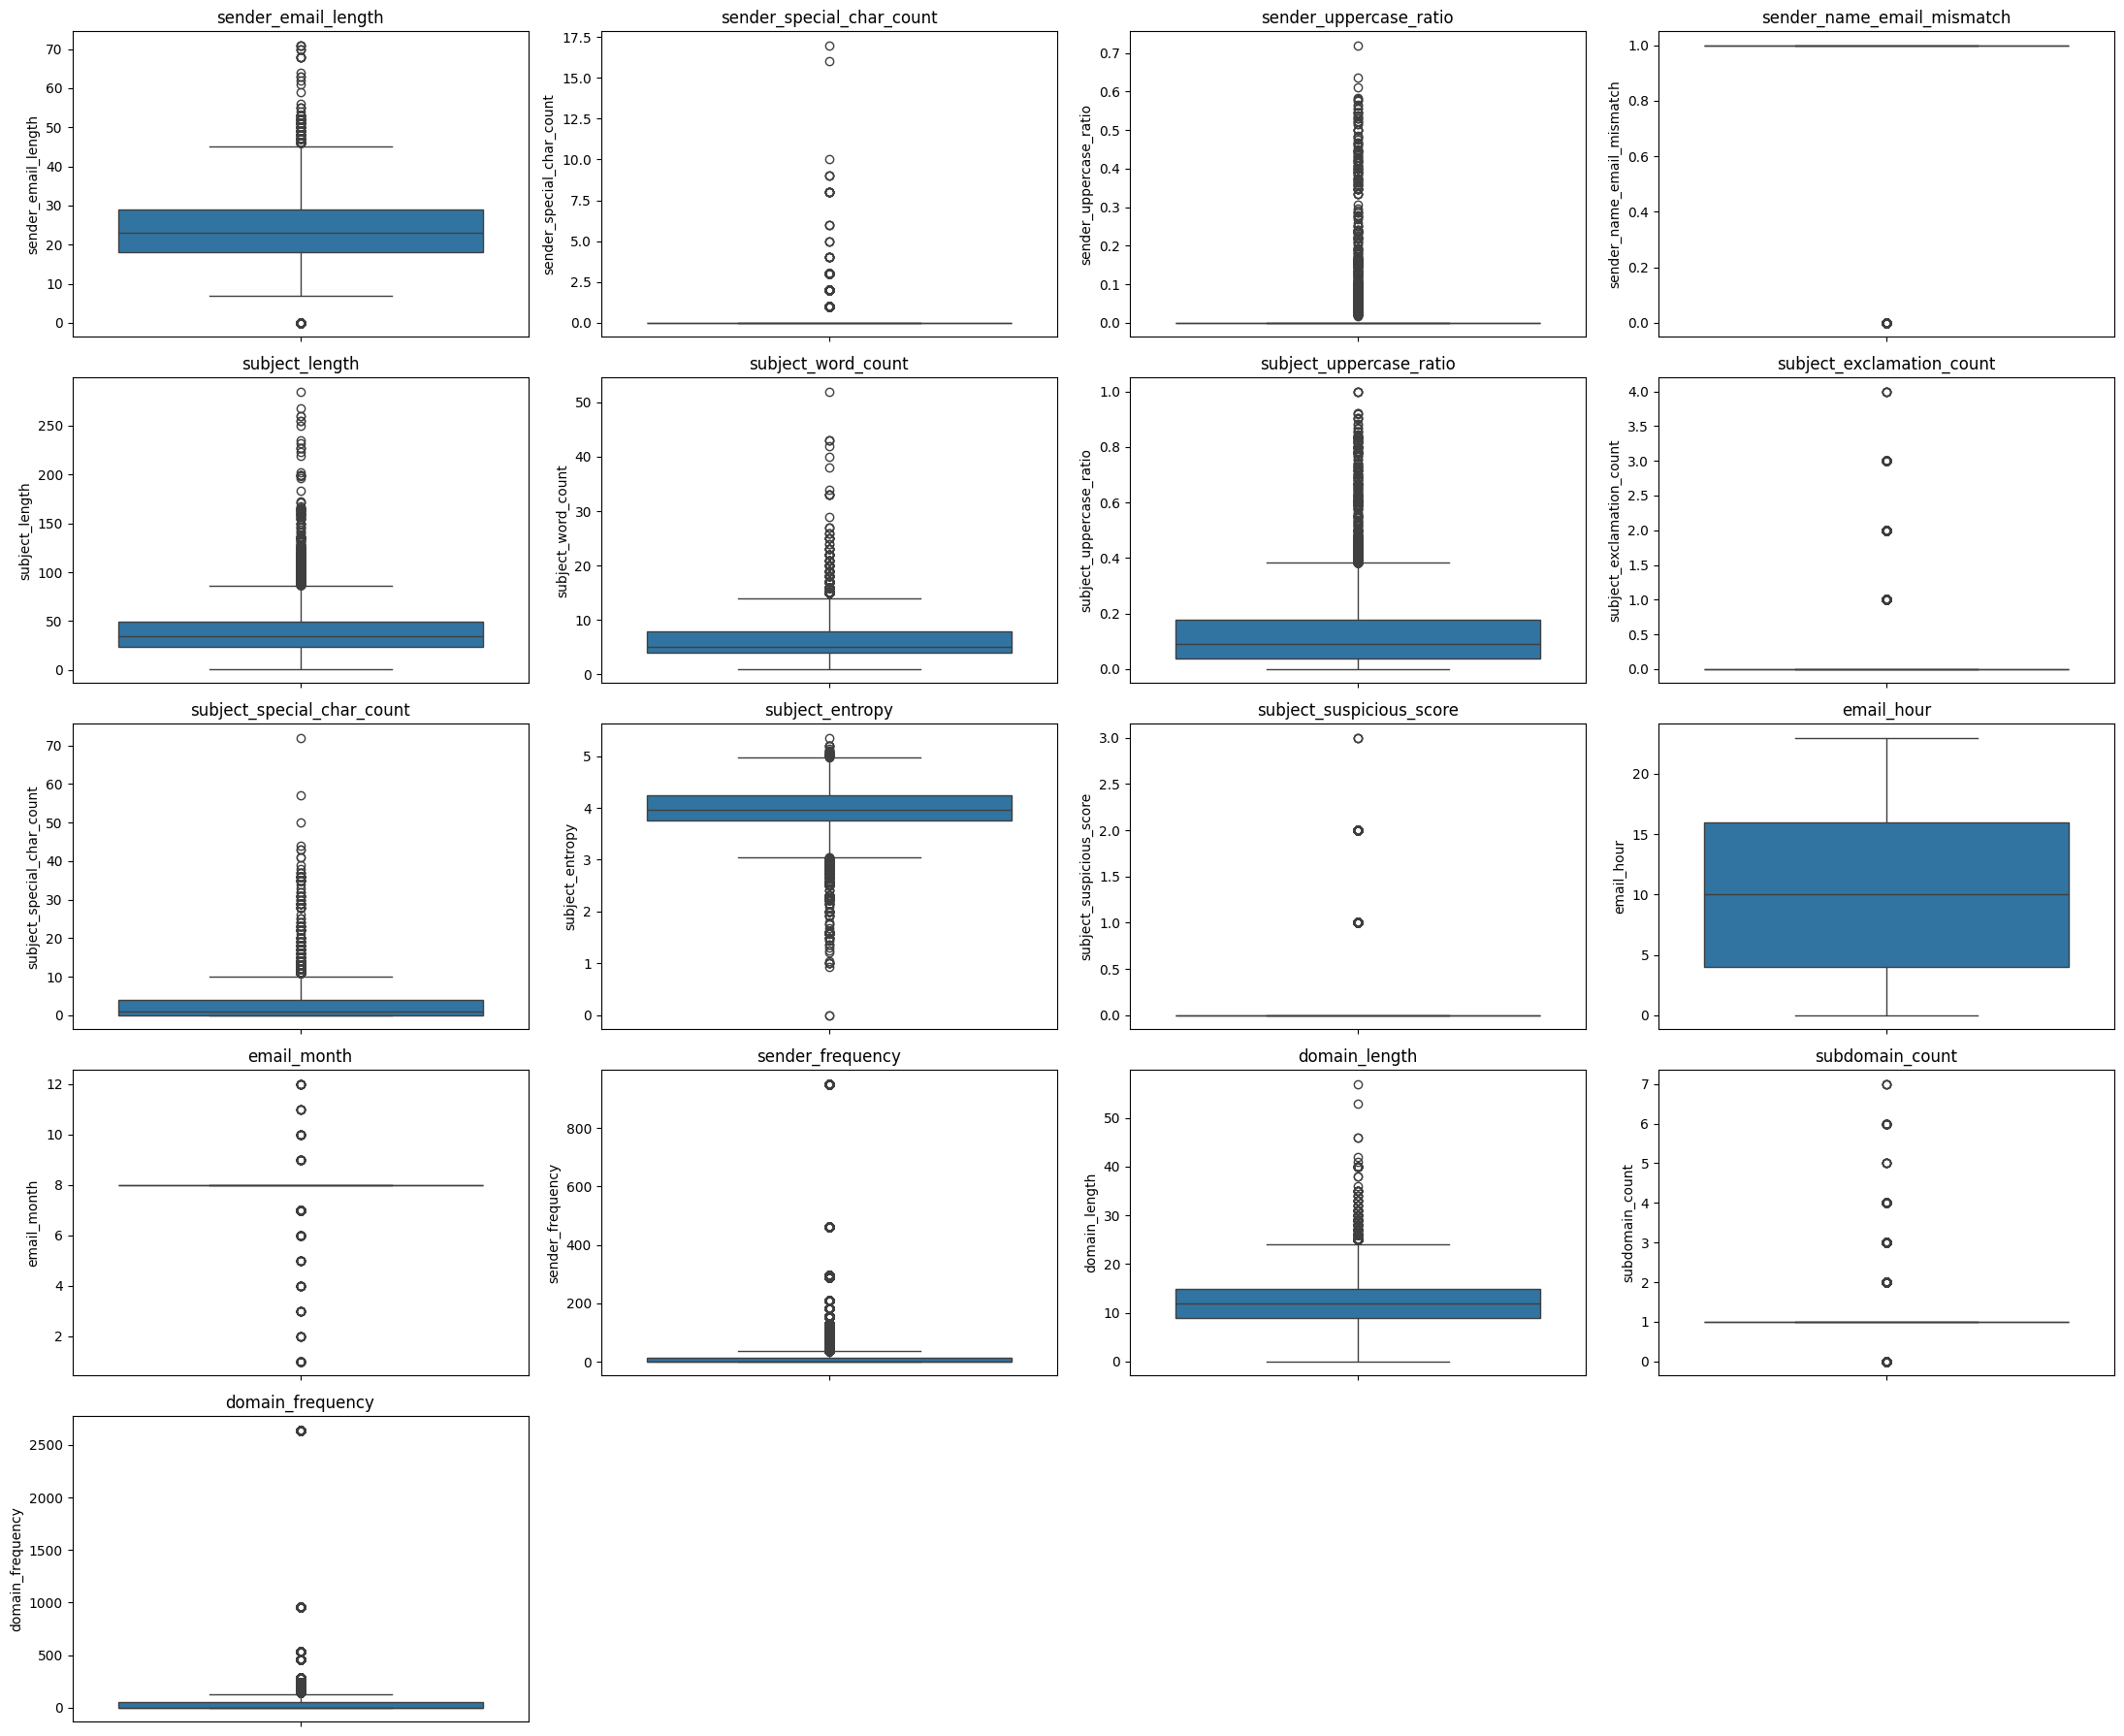

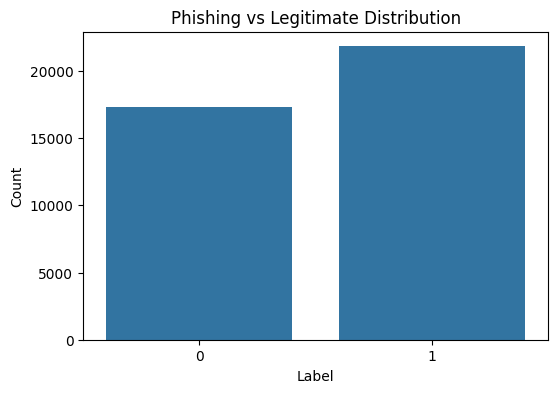

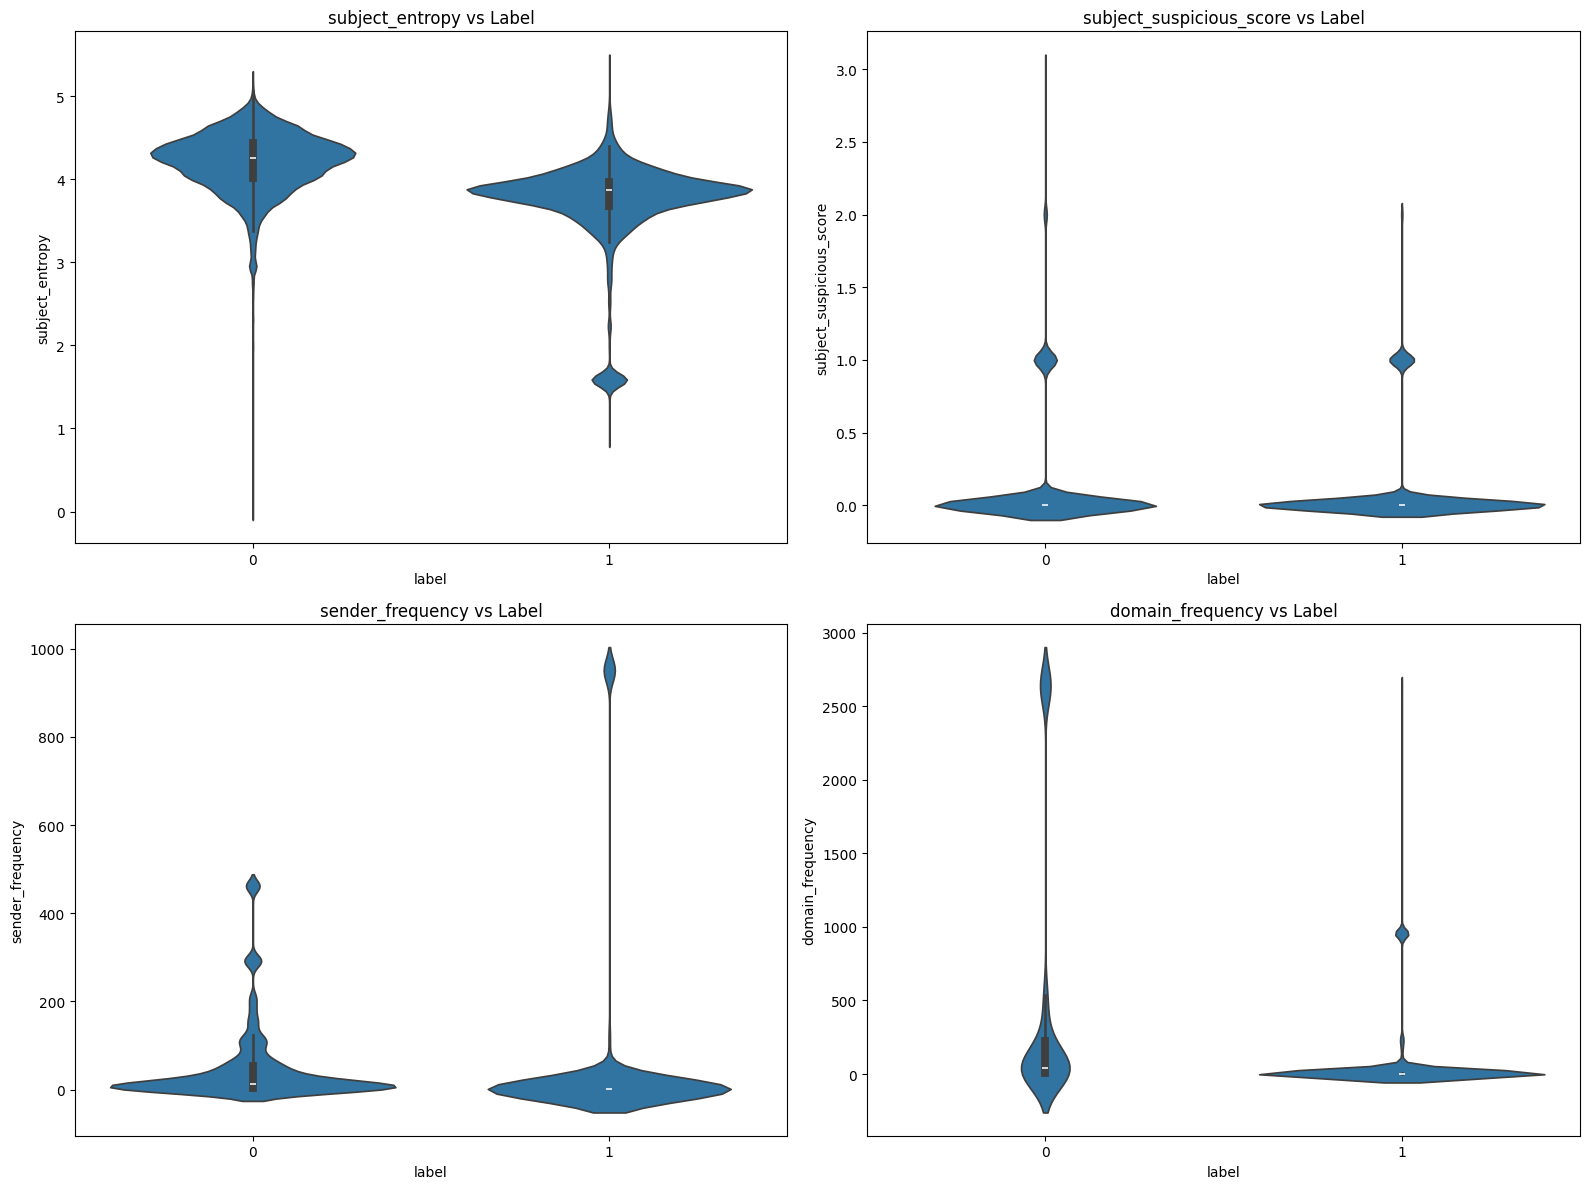

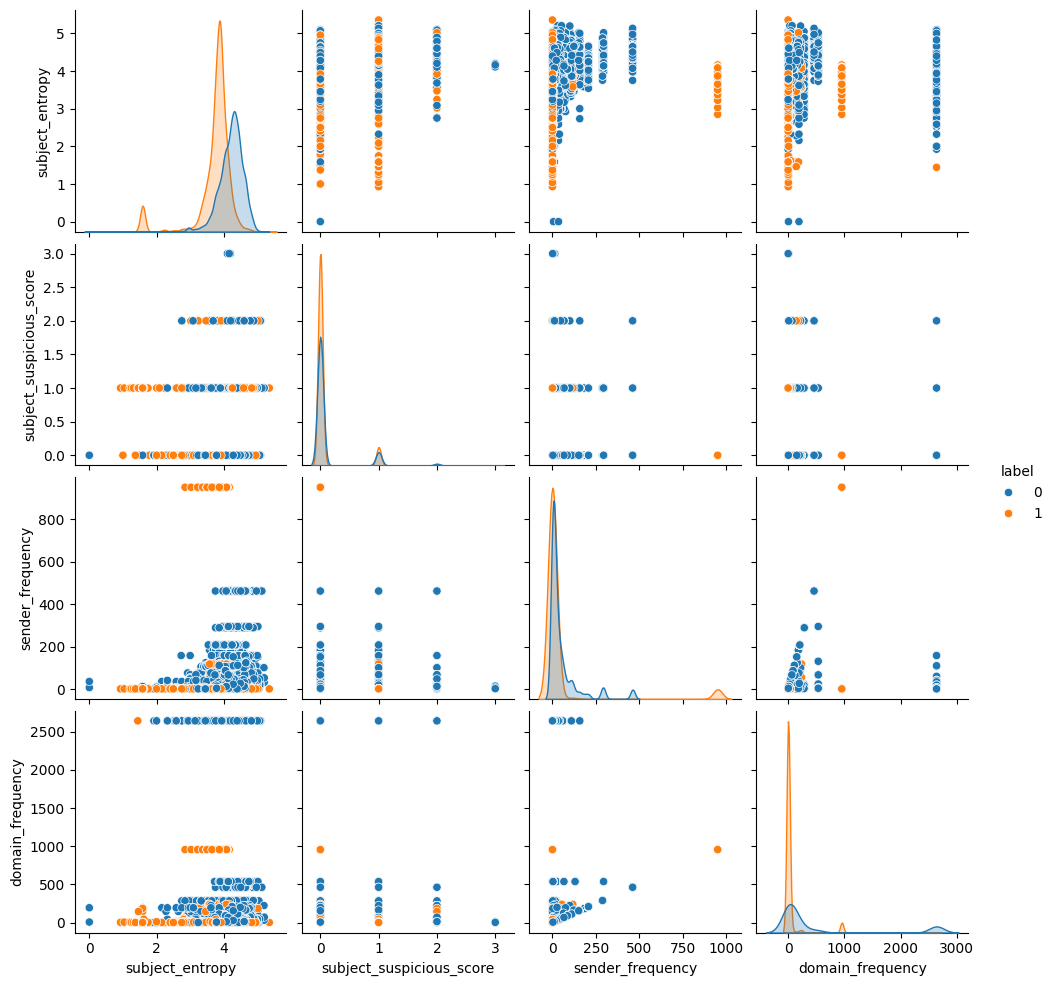

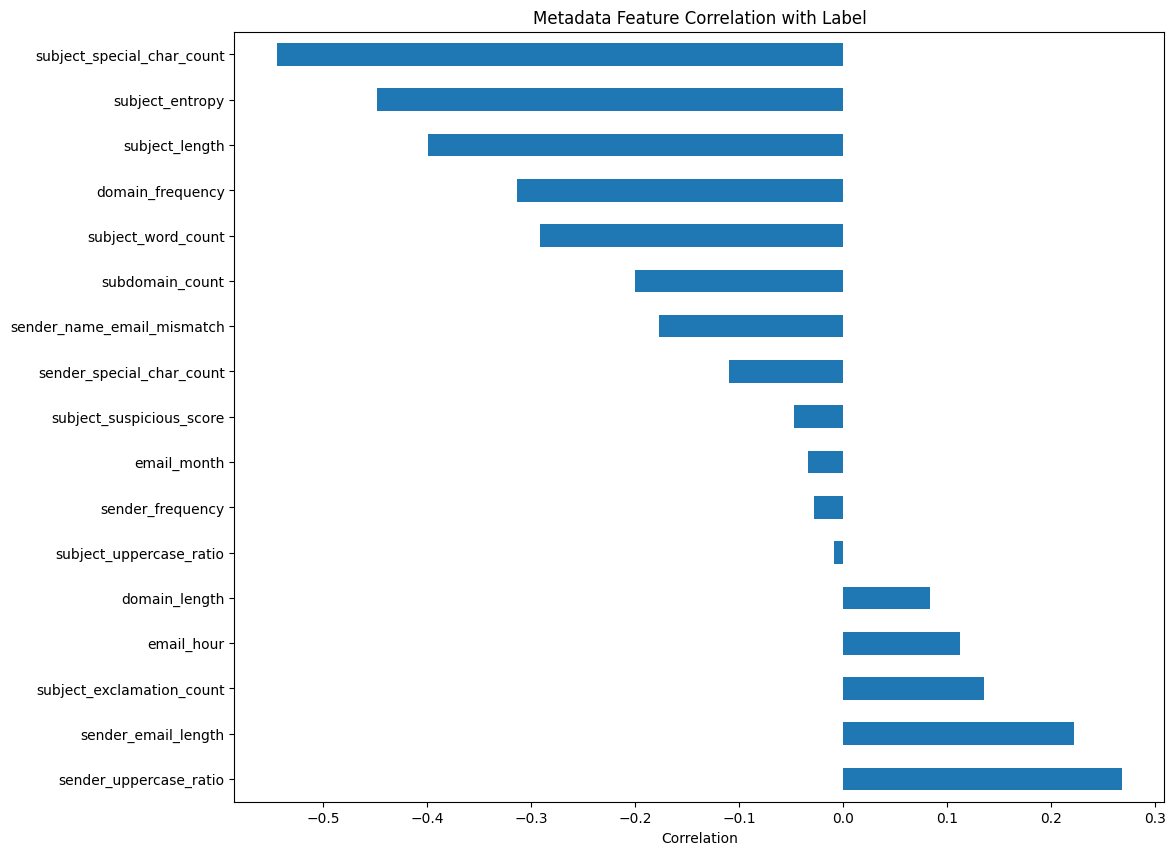

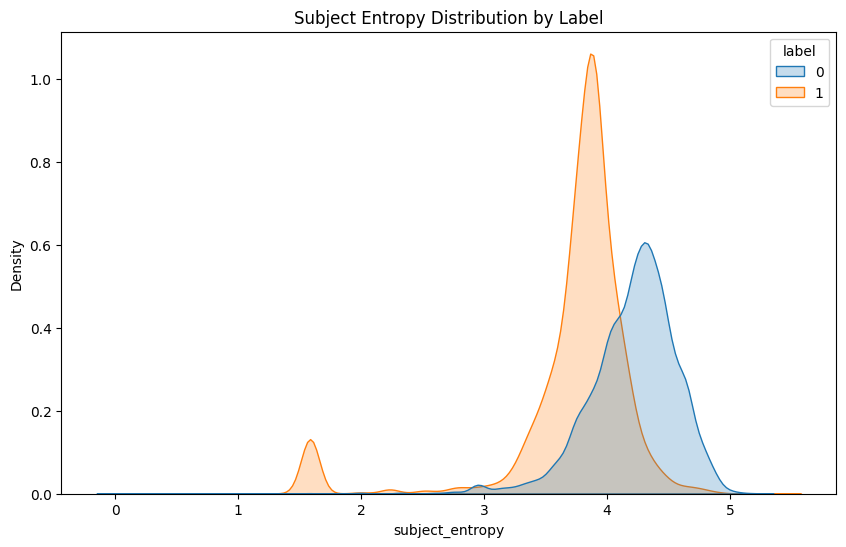

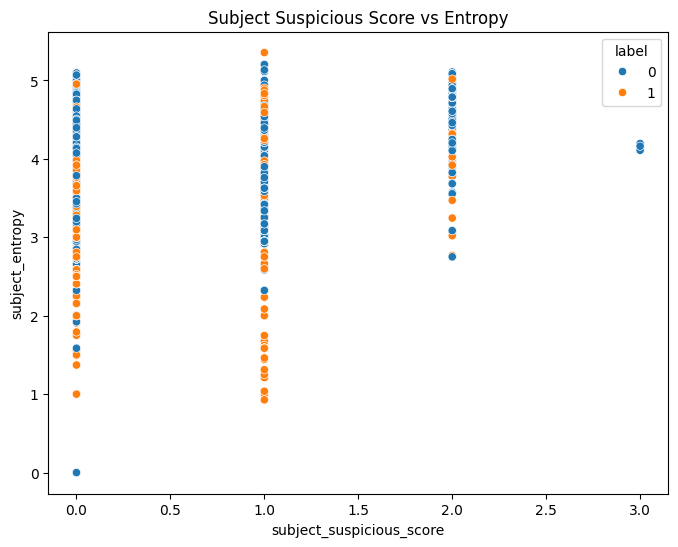

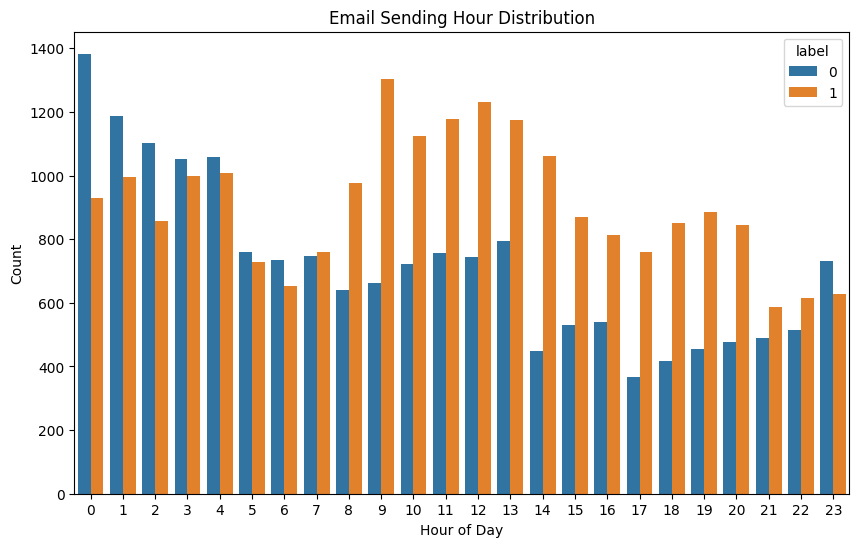

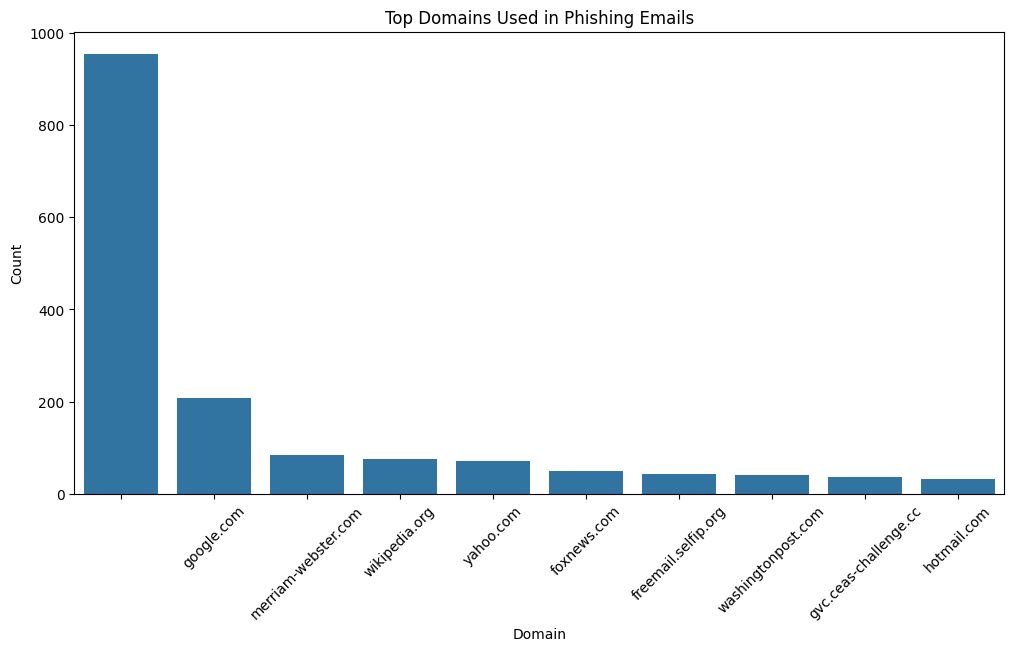

In [ ]:
# =========================================================
# IMPORT VISUALIZATION LIBRARIES
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# SELECT METADATA NUMERICAL FEATURES
# =========================================================

numerical_features = df_meta[[
    'sender_email_length',
    'sender_special_char_count',
    'sender_uppercase_ratio',
    'sender_name_email_mismatch',
    'subject_length',
    'subject_word_count',
    'subject_uppercase_ratio',
    'subject_exclamation_count',
    'subject_special_char_count',
    'subject_entropy',
    'subject_suspicious_score',
    'email_hour',
    'email_month',
    'sender_frequency',
    'domain_length',
    'subdomain_count',
    'domain_frequency'
]]

# =========================================================
# CORRELATION HEATMAP
# =========================================================

correlation_matrix = numerical_features.corr()

plt.figure(figsize=(18,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Metadata Feature Correlation Heatmap')

plt.show()

# =========================================================
# FEATURE DISTRIBUTION PLOTS
# =========================================================

numerical_features.hist(
    figsize=(20,18),
    bins=30
)

plt.tight_layout()

plt.show()

# =========================================================
# BOXPLOTS FOR OUTLIER DETECTION
# =========================================================

plt.figure(figsize=(22,18))

for i, column in enumerate(numerical_features.columns, 1):

    plt.subplot(5,4,i)

    sns.boxplot(y=numerical_features[column])

    plt.title(column)

plt.tight_layout()

plt.show()

# =========================================================
# LABEL DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(x=df_meta['label'])

plt.title('Phishing vs Legitimate Distribution')

plt.xlabel('Label')

plt.ylabel('Count')

plt.show()

# =========================================================
# VIOLIN PLOTS
# =========================================================

features_to_plot = [
    'subject_entropy',
    'subject_suspicious_score',
    'sender_frequency',
    'domain_frequency'
]

plt.figure(figsize=(16,12))

for i, feature in enumerate(features_to_plot, 1):

    plt.subplot(2,2,i)

    sns.violinplot(
        x=df_meta['label'],
        y=df_meta[feature]
    )

    plt.title(f'{feature} vs Label')

plt.tight_layout()

plt.show()

# =========================================================
# PAIRPLOT
# =========================================================

pairplot_features = [
    'subject_entropy',
    'subject_suspicious_score',
    'sender_frequency',
    'domain_frequency',
    'label'
]

sns.pairplot(
    df_meta[pairplot_features],
    hue='label'
)

plt.show()

# =========================================================
# FEATURE CORRELATION WITH LABEL
# =========================================================

feature_correlation = df_meta[[
    'sender_email_length',
    'sender_special_char_count',
    'sender_uppercase_ratio',
    'sender_name_email_mismatch',
    'subject_length',
    'subject_word_count',
    'subject_uppercase_ratio',
    'subject_exclamation_count',
    'subject_special_char_count',
    'subject_entropy',
    'subject_suspicious_score',
    'email_hour',
    'email_month',
    'sender_frequency',
    'domain_length',
    'subdomain_count',
    'domain_frequency',
    'label'
]].corr()['label'].sort_values(ascending=False)

plt.figure(figsize=(12,10))

feature_correlation.drop('label').plot(
    kind='barh'
)

plt.title('Metadata Feature Correlation with Label')

plt.xlabel('Correlation')

plt.show()

# =========================================================
# KDE PLOT
# =========================================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_meta,
    x='subject_entropy',
    hue='label',
    fill=True
)

plt.title('Subject Entropy Distribution by Label')

plt.show()

# =========================================================
# SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_meta,
    x='subject_suspicious_score',
    y='subject_entropy',
    hue='label'
)

plt.title('Subject Suspicious Score vs Entropy')

plt.show()

# =========================================================
# EMAIL HOUR DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x=df_meta['email_hour'],
    hue=df_meta['label']
)

plt.title('Email Sending Hour Distribution')

plt.xlabel('Hour of Day')

plt.ylabel('Count')

plt.show()

# =========================================================
# TOP PHISHING DOMAINS
# =========================================================

top_domains = (
    df_meta[df_meta['label'] == 1]['sender_domain']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_domains.index,
    y=top_domains.values
)

plt.xticks(rotation=45)

plt.title('Top Domains Used in Phishing Emails')

plt.xlabel('Domain')

plt.ylabel('Count')

plt.show()

In [ ]:

print("DROPPING BODY COLUMN")


df_meta = df_meta.drop(columns=['sender_domain'])

df_meta = df_meta.drop(columns=['attachment_names'])


# OUTPUTS

print("\nUpdated Dataset Shape:")

print(df_meta.shape)

print("\nRemaining Columns:\n")

print(df_meta.columns)

DROPPING BODY COLUMN

Updated Dataset Shape:
(39139, 36)

Remaining Columns:

Index(['body', 'label', 'urls', 'has_attachment', 'attachment_count',
       'sender_email_length', 'sender_has_numbers',
       'sender_special_char_count', 'sender_uppercase_ratio',
       'sender_name_email_mismatch', 'subject_length', 'subject_word_count',
       'subject_uppercase_ratio', 'subject_exclamation_count',
       'subject_special_char_count', 'subject_has_reply_forward',
       'subject_entropy', 'subject_suspicious_score', 'email_hour',
       'email_day', 'email_month', 'is_weekend', 'is_night_email',
       'sender_frequency', 'domain_length', 'domain_has_hyphen',
       'subdomain_count', 'suspicious_tld', 'is_free_provider',
       'valid_sender_email', 'domain_frequency', 'subject_frequency',
       'has_empty_subject', 'timezone', 'subject_url_count',
       'subject_unique_char_ratio'],
      dtype='object')


In [ ]:
df_meta = df_meta.drop(columns=['body'])
print(df_meta.columns)

Index(['label', 'urls', 'has_attachment', 'attachment_count',
       'sender_email_length', 'sender_has_numbers',
       'sender_special_char_count', 'sender_uppercase_ratio',
       'sender_name_email_mismatch', 'subject_length', 'subject_word_count',
       'subject_uppercase_ratio', 'subject_exclamation_count',
       'subject_special_char_count', 'subject_has_reply_forward',
       'subject_entropy', 'subject_suspicious_score', 'email_hour',
       'email_day', 'email_month', 'is_weekend', 'is_night_email',
       'sender_frequency', 'domain_length', 'domain_has_hyphen',
       'subdomain_count', 'suspicious_tld', 'is_free_provider',
       'valid_sender_email', 'domain_frequency', 'subject_frequency',
       'has_empty_subject', 'timezone', 'subject_url_count',
       'subject_unique_char_ratio'],
      dtype='object')


In [ ]:
# Saving the final processed dataset with all engineered features to Google Drive
df_meta.to_csv(
    '/content/drive/MyDrive/Phishing_Project/final_dataset/final_preprocessed_dataset_aaryan.csv',
    index=False
)


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df_meta = pd.read_csv('/content/drive/MyDrive/Phishing_Project/final_dataset/final_preprocessed_dataset_aaryan.csv')
df_meta.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,urls,has_attachment,attachment_count,sender_email_length,sender_has_numbers,sender_special_char_count,sender_uppercase_ratio,sender_name_email_mismatch,subject_length,...,subdomain_count,suspicious_tld,is_free_provider,valid_sender_email,domain_frequency,subject_frequency,has_empty_subject,timezone,subject_url_count,subject_unique_char_ratio
0,1,1,0,0,15,0,0,0.066667,0,25,...,1,0,0,1,6,7,0,NaN,0,0.480000
1,1,1,0,0,22,1,1,0.000000,1,22,...,1,0,0,0,1,11,0,NaN,0,0.590909
2,1,1,0,0,39,0,1,0.025641,1,20,...,2,0,0,1,1,2930,0,NaN,0,0.800000
3,0,1,0,0,17,0,0,0.000000,1,150,...,1,0,0,1,164,3,0,NaN,0,0.253333
4,1,1,0,0,32,1,0,0.000000,1,26,...,1,0,0,1,2,1,0,NaN,0,0.615385


In [ ]:
X = df_meta.drop(columns=['label'])
y = df_meta['label'] # SHOW OUTPUTS print("\nFeature Matrix Shape:")
print(X.shape)
print("\nLabel Shape:")
print(y.shape)
print("\nFirst 5 Rows of Features:")
print(X.head())
print("\nLabel Distribution:")
print(y.value_counts())

(39139, 34)

Label Shape:
(39139,)

First 5 Rows of Features:
   urls  has_attachment  attachment_count  sender_email_length  \
0     1               0                 0                   15   
1     1               0                 0                   22   
2     1               0                 0                   39   
3     1               0                 0                   17   
4     1               0                 0                   32   

   sender_has_numbers  sender_special_char_count  sender_uppercase_ratio  \
0                   0                          0                0.066667   
1                   1                          1                0.000000   
2                   0                          1                0.025641   
3                   0                          0                0.000000   
4                   1                          0                0.000000   

   sender_name_email_mismatch  subject_length  subject_word_count  ...  \
0         

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'email_day',
    'timezone'
]

encoder = LabelEncoder()

for col in categorical_cols:

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    print(f"\nEncoded Column: {col}")

    print(X[col].head())

# OUTPUT

print("\nUpdated Dataset Preview:")

print(X.head())


Encoded Column: email_day
0    5
1    5
2    6
3    5
4    5
Name: email_day, dtype: int64

Encoded Column: timezone
0    0
1    0
2    0
3    0
4    0
Name: timezone, dtype: int64

Updated Dataset Preview:
   urls  has_attachment  attachment_count  sender_email_length  \
0     1               0                 0                   15   
1     1               0                 0                   22   
2     1               0                 0                   39   
3     1               0                 0                   17   
4     1               0                 0                   32   

   sender_has_numbers  sender_special_char_count  sender_uppercase_ratio  \
0                   0                          0                0.066667   
1                   1                          1                0.000000   
2                   0                          1                0.025641   
3                   0                          0                0.000000   
4              

In [ ]:
X.columns

Index(['urls', 'has_attachment', 'attachment_count', 'sender_email_length',
       'sender_has_numbers', 'sender_special_char_count',
       'sender_uppercase_ratio', 'sender_name_email_mismatch',
       'subject_length', 'subject_word_count', 'subject_uppercase_ratio',
       'subject_exclamation_count', 'subject_special_char_count',
       'subject_has_reply_forward', 'subject_entropy',
       'subject_suspicious_score', 'email_hour', 'email_day', 'email_month',
       'is_weekend', 'is_night_email', 'sender_frequency', 'domain_length',
       'domain_has_hyphen', 'subdomain_count', 'suspicious_tld',
       'is_free_provider', 'valid_sender_email', 'domain_frequency',
       'subject_frequency', 'has_empty_subject', 'timezone',
       'subject_url_count', 'subject_unique_char_ratio'],
      dtype='object')

In [ ]:
# =========================================================
# STEP 3 — TRAIN TEST SPLIT
# =========================================================

print("STEP 3: TRAIN TEST SPLIT")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# OUTPUTS

print("\nX_train Shape:")
print(X_train.shape)

print("\nX_test Shape:")
print(X_test.shape)

print("\ny_train Distribution:")
print(y_train.value_counts())

print("\ny_test Distribution:")
print(y_test.value_counts())

STEP 3: TRAIN TEST SPLIT

X_train Shape:
(31311, 34)

X_test Shape:
(7828, 34)

y_train Distribution:
label
1    17461
0    13850
Name: count, dtype: int64

y_test Distribution:
label
1    4366
0    3462
Name: count, dtype: int64


In [ ]:
# =========================================================
# STEP 4 — FEATURE SCALING
# =========================================================

print("STEP 4: FEATURE SCALING")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# OUTPUTS

print("\nScaled Training Shape:")
print(X_train_scaled.shape)

print("\nScaled Testing Shape:")
print(X_test_scaled.shape)

print("\nFirst Scaled Row:")

print(X_train_scaled[0])

STEP 4: FEATURE SCALING

Scaled Training Shape:
(31311, 34)

Scaled Testing Shape:
(7828, 34)

First Scaled Row:
[ 0.70380652  0.          0.         -0.09039127 -0.39083266 -0.48271849
 -0.38112817  0.27758374  0.39434422  0.30013289 -0.11222856 -0.22885404
 -0.79993567 -0.59506832  0.25738854 -0.30837362 -1.20805228  0.86021542
  0.05092632 -0.07030441  1.4870725  -0.29350619  0.51344608 -0.27213985
 -0.37240789 -0.06580467 -0.28466054  0.17583126 -0.35430344 -0.37032119
 -0.02651646  0.         -0.01598645 -0.79556828]


In [ ]:
# =========================================================
# BLOCK 1 — SENDER ANALYSIS FEATURES
# =========================================================

print("BLOCK 1: SENDER FEATURES")

sender_features = [

    'sender_email_length',
    'sender_special_char_count',
    'sender_uppercase_ratio',
    'domain_length',
    'subdomain_count',
    'domain_frequency',
    'domain_has_hyphen',
    'suspicious_tld',
    'is_free_provider'
]

X_sender = df_meta[sender_features]

y = df_meta['label']

# OUTPUTS

print("\nSender Feature Shape:")

print(X_sender.shape)

print("\nFirst 5 Rows:")

print(X_sender.head())

BLOCK 1: SENDER FEATURES

Sender Feature Shape:
(39139, 9)

First 5 Rows:
   sender_email_length  sender_special_char_count  sender_uppercase_ratio  \
0                   15                          0                0.066667   
1                   22                          1                0.000000   
2                   39                          1                0.025641   
3                   17                          0                0.000000   
4                   32                          0                0.000000   

   domain_length  subdomain_count  domain_frequency  domain_has_hyphen  \
0              9                1                 6                  0   
1              9                1                 1                  0   
2             19                2                 1                  0   
3              9                1               164                  0   
4             19                1                 2                  0   

   suspicious_tld 

In [ ]:
# =========================================================
# BLOCK 2 — SPOOF FEATURES
# =========================================================

print("BLOCK 2: SPOOF FEATURES")

spoof_features = [

    'sender_name_email_mismatch',
    'valid_sender_email',
    'subject_uppercase_ratio',
    'subject_special_char_count',
    'subject_entropy',
    'subject_suspicious_score'
]

X_spoof = df_meta[spoof_features]

# OUTPUTS

print("\nSpoof Feature Shape:")

print(X_spoof.shape)

print("\nFirst 5 Rows:")

print(X_spoof.head())

BLOCK 2: SPOOF FEATURES

Spoof Feature Shape:
(39139, 6)

First 5 Rows:
   sender_name_email_mismatch  valid_sender_email  subject_uppercase_ratio  \
0                           0                   1                 0.040000   
1                           1                   0                 0.136364   
2                           1                   1                 0.250000   
3                           1                   1                 0.086667   
4                           1                   1                 0.153846   

   subject_special_char_count  subject_entropy  subject_suspicious_score  
0                           0         3.208884                         0  
1                           0         3.459432                         0  
2                           1         3.884184                         0  
3                          18         4.615787                         0  
4                           0         3.844107                         0  


In [ ]:
# =========================================================
# BLOCK 3 — HEADER CLASSIFIER FEATURES
# =========================================================

print("BLOCK 3: HEADER FEATURES")

header_features = [

    'sender_email_length',
    'sender_special_char_count',
    'sender_uppercase_ratio',
    'sender_name_email_mismatch',
    'subject_length',
    'subject_word_count',
    'subject_uppercase_ratio',
    'subject_exclamation_count',
    'subject_special_char_count',
    'subject_entropy',
    'subject_suspicious_score',
    'email_hour',
    'email_month',
    'sender_frequency',
    'domain_length',
    'subdomain_count',
    'domain_frequency',
    'suspicious_tld',
    'is_free_provider'
]

X_header = df_meta[header_features]

# OUTPUTS

print("\nHeader Feature Shape:")

print(X_header.shape)

print("\nFirst 5 Rows:")

print(X_header.head())

BLOCK 3: HEADER FEATURES

Header Feature Shape:
(39139, 19)

First 5 Rows:
   sender_email_length  sender_special_char_count  sender_uppercase_ratio  \
0                   15                          0                0.066667   
1                   22                          1                0.000000   
2                   39                          1                0.025641   
3                   17                          0                0.000000   
4                   32                          0                0.000000   

   sender_name_email_mismatch  subject_length  subject_word_count  \
0                           0              25                   6   
1                           1              22                   3   
2                           1              20                   4   
3                           1             150                  10   
4                           1              26                   1   

   subject_uppercase_ratio  subject_exclamation

In [ ]:
# =========================================================
# BLOCK 4 — SENDER SPLIT
# =========================================================

print("BLOCK 4: SENDER SPLIT")

from sklearn.model_selection import train_test_split

X_sender_train, X_sender_test, y_sender_train, y_sender_test = train_test_split(

    X_sender,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# OUTPUTS

print("\nTraining Shape:")

print(X_sender_train.shape)

print("\nTesting Shape:")

print(X_sender_test.shape)

BLOCK 4: SENDER SPLIT

Training Shape:
(31311, 9)

Testing Shape:
(7828, 9)


In [ ]:
# =========================================================
# BLOCK 5 — SPOOF SPLIT
# =========================================================

print("BLOCK 5: SPOOF SPLIT")

X_spoof_train, X_spoof_test, y_spoof_train, y_spoof_test = train_test_split(

    X_spoof,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# OUTPUTS

print("\nTraining Shape:")

print(X_spoof_train.shape)

print("\nTesting Shape:")

print(X_spoof_test.shape)

BLOCK 5: SPOOF SPLIT

Training Shape:
(31311, 6)

Testing Shape:
(7828, 6)


In [ ]:
# =========================================================
# BLOCK 6 — HEADER SPLIT
# =========================================================

print("BLOCK 6: HEADER SPLIT")

X_header_train, X_header_test, y_header_train, y_header_test = train_test_split(

    X_header,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# OUTPUTS

print("\nTraining Shape:")

print(X_header_train.shape)

print("\nTesting Shape:")

print(X_header_test.shape)

BLOCK 6: HEADER SPLIT

Training Shape:
(31311, 19)

Testing Shape:
(7828, 19)


In [ ]:

 #IMPORT LIBRARIES

print("IMPORTING LIBRARIES")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import os

IMPORTING LIBRARIES


In [ ]:
# =========================================================
# BLOCK 4 — TRAIN SENDER MODEL
# =========================================================

print("TRAINING SENDER MODEL")

sender_model = RandomForestClassifier(

    n_estimators=200,
    random_state=42
)

sender_model.fit(

    X_sender_train,
    y_sender_train
)

print("\nSender Model Training Complete")


TRAINING SENDER MODEL

Sender Model Training Complete


In [ ]:
# =========================================================
# BLOCK 5 — EVALUATE SENDER MODEL
# =========================================================

print("EVALUATING SENDER MODEL")

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

sender_pred = sender_model.predict(
    X_sender_test
)

sender_probs = sender_model.predict_proba(
    X_sender_test
)[:,1]

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------

print("\nAccuracy:")

print(
    accuracy_score(
        y_sender_test,
        sender_pred
    )
)

print("\nPrecision:")

print(
    precision_score(
        y_sender_test,
        sender_pred
    )
)

print("\nRecall:")

print(
    recall_score(
        y_sender_test,
        sender_pred
    )
)

print("\nF1 Score:")

print(
    f1_score(
        y_sender_test,
        sender_pred
    )
)

print("\nROC-AUC Score:")

print(
    roc_auc_score(
        y_sender_test,
        sender_probs
    )
)

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_sender_test,
        sender_pred
    )
)

EVALUATING SENDER MODEL

Accuracy:
0.9426417986714358

Precision:
0.9368726299353112

Recall:
0.961978928080623

F1 Score:
0.9492598033676122

ROC-AUC Score:
0.9807657472412343

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3462
           1       0.94      0.96      0.95      4366

    accuracy                           0.94      7828
   macro avg       0.94      0.94      0.94      7828
weighted avg       0.94      0.94      0.94      7828



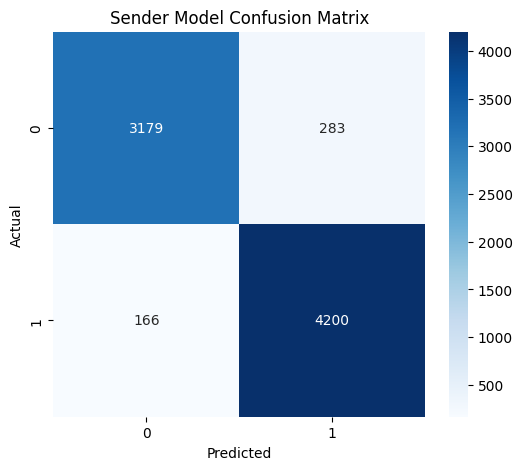

In [ ]:
# =========================================================
# BLOCK 6 — SENDER CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_sender_test,
    sender_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Sender Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

TRAINING AND EVALUATING SPOOF MODEL

Accuracy:
0.9506898313745529

Precision:
0.9518619436875567

Recall:
0.9601465872652314

F1 Score:
0.9559863169897378

ROC-AUC Score:
0.9871873422933847

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      3462
           1       0.95      0.96      0.96      4366

    accuracy                           0.95      7828
   macro avg       0.95      0.95      0.95      7828
weighted avg       0.95      0.95      0.95      7828



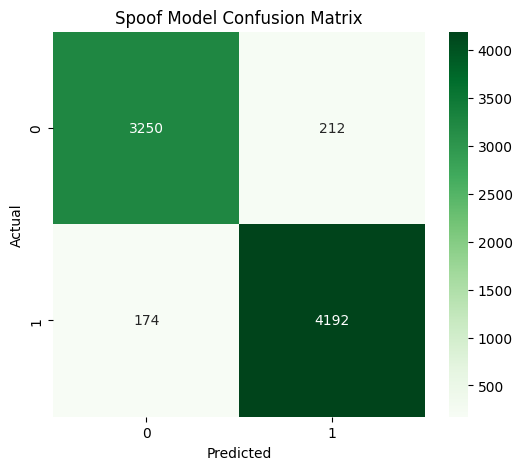


First 10 Confidence Scores:

[0. 0. 0. 0. 0. 0. 1. 1. 0. 1.]


In [ ]:
# =========================================================
# TRAIN + EVALUATE SPOOF MODEL
# =========================================================

print("TRAINING AND EVALUATING SPOOF MODEL")

# ---------------------------------------------------------
# TRAIN MODEL
# ---------------------------------------------------------

spoof_model = RandomForestClassifier(

    n_estimators=200,
    random_state=42
)

spoof_model.fit(

    X_spoof_train,
    y_spoof_train
)

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

spoof_pred = spoof_model.predict(
    X_spoof_test
)

spoof_probs = spoof_model.predict_proba(
    X_spoof_test
)[:,1]

# ---------------------------------------------------------
# EVALUATION METRICS
# ---------------------------------------------------------

print("\nAccuracy:")

print(
    accuracy_score(
        y_spoof_test,
        spoof_pred
    )
)

print("\nPrecision:")

print(
    precision_score(
        y_spoof_test,
        spoof_pred
    )
)

print("\nRecall:")

print(
    recall_score(
        y_spoof_test,
        spoof_pred
    )
)

print("\nF1 Score:")

print(
    f1_score(
        y_spoof_test,
        spoof_pred
    )
)

print("\nROC-AUC Score:")

print(
    roc_auc_score(
        y_spoof_test,
        spoof_probs
    )
)

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_spoof_test,
        spoof_pred
    )
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_spoof_test,
    spoof_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Spoof Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ---------------------------------------------------------
# CONFIDENCE SCORES
# ---------------------------------------------------------

print("\nFirst 10 Confidence Scores:\n")

print(spoof_probs[:10])

TRAINING AND EVALUATING XGBOOST HEADER MODEL

Accuracy:
0.9822432294328053

Precision:
0.978275627970129

Recall:
0.9901511681172698

F1 Score:
0.9841775754126352

ROC-AUC Score:
0.997849500353686

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3462
           1       0.98      0.99      0.98      4366

    accuracy                           0.98      7828
   macro avg       0.98      0.98      0.98      7828
weighted avg       0.98      0.98      0.98      7828



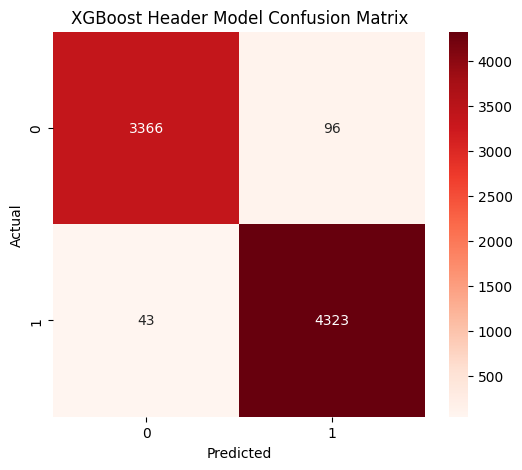


First 10 Confidence Scores:

[1.4616184e-05 3.5904177e-05 2.3759043e-04 2.8901350e-05 3.3664142e-05
 5.1356578e-06 9.9995148e-01 9.9875939e-01 3.5284069e-05 9.9997854e-01]


In [ ]:
# =========================================================
# TRAIN + EVALUATE HEADER MODEL USING XGBOOST
# =========================================================

print("TRAINING AND EVALUATING XGBOOST HEADER MODEL")

# ---------------------------------------------------------
# IMPORT XGBOOST
# ---------------------------------------------------------

from xgboost import XGBClassifier

# ---------------------------------------------------------
# CREATE MODEL
# ---------------------------------------------------------

header_model = XGBClassifier(

    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# ---------------------------------------------------------
# TRAIN MODEL
# ---------------------------------------------------------

header_model.fit(

    X_header_train,
    y_header_train
)

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

header_pred = header_model.predict(
    X_header_test
)

header_probs = header_model.predict_proba(
    X_header_test
)[:,1]

# ---------------------------------------------------------
# EVALUATION METRICS
# ---------------------------------------------------------

print("\nAccuracy:")

print(
    accuracy_score(
        y_header_test,
        header_pred
    )
)

print("\nPrecision:")

print(
    precision_score(
        y_header_test,
        header_pred
    )
)

print("\nRecall:")

print(
    recall_score(
        y_header_test,
        header_pred
    )
)

print("\nF1 Score:")

print(
    f1_score(
        y_header_test,
        header_pred
    )
)

print("\nROC-AUC Score:")

print(
    roc_auc_score(
        y_header_test,
        header_probs
    )
)

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_header_test,
        header_pred
    )
)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_header_test,
    header_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost Header Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ---------------------------------------------------------
# CONFIDENCE SCORES
# ---------------------------------------------------------

print("\nFirst 10 Confidence Scores:\n")

print(header_probs[:10])


Top 15 Important Features:

                       Feature  Importance
13            sender_frequency    0.502863
8   subject_special_char_count    0.110802
2       sender_uppercase_ratio    0.091854
3   sender_name_email_mismatch    0.071636
7    subject_exclamation_count    0.034046
16            domain_frequency    0.031336
18            is_free_provider    0.028852
15             subdomain_count    0.018335
10    subject_suspicious_score    0.017406
0          sender_email_length    0.016158
6      subject_uppercase_ratio    0.015153
1    sender_special_char_count    0.013405
12                 email_month    0.012785
9              subject_entropy    0.008553
14               domain_length    0.007970


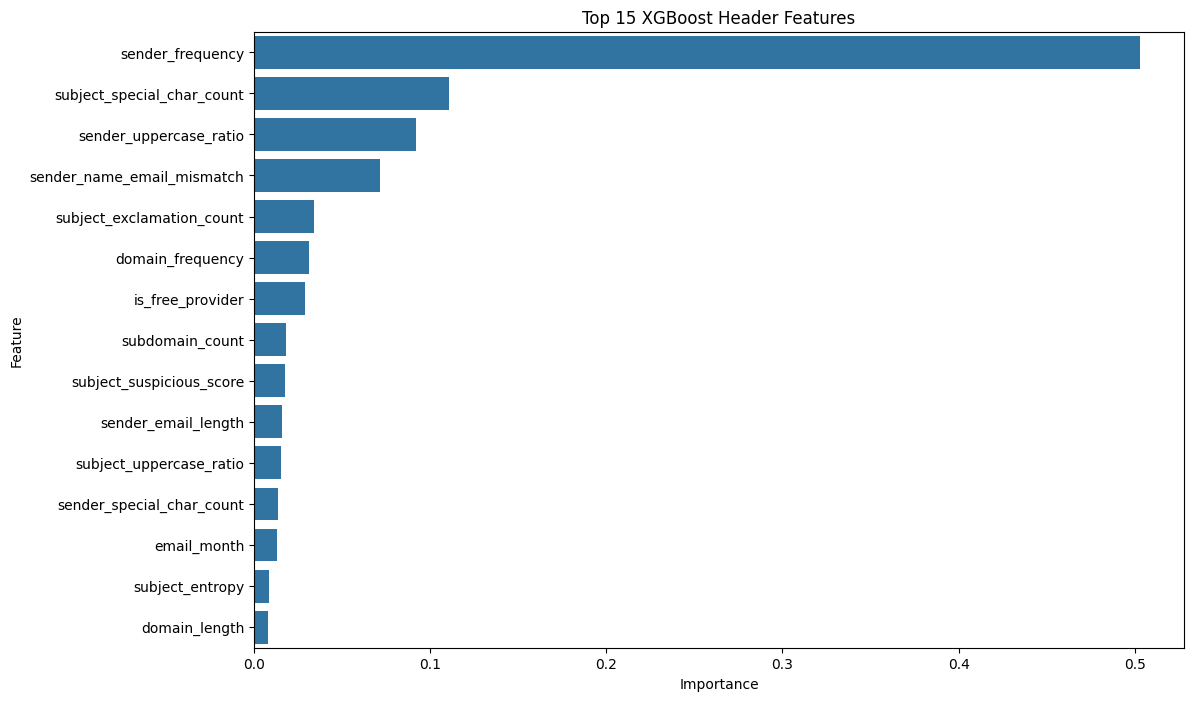

In [ ]:
# =========================================================
# XGBOOST FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({

    'Feature': X_header.columns,

    'Importance': header_model.feature_importances_
})

importance = importance.sort_values(

    by='Importance',
    ascending=False
)

print("\nTop 15 Important Features:\n")

print(importance.head(15))

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(15),

    x='Importance',

    y='Feature'
)

plt.title("Top 15 XGBoost Header Features")

plt.show()

In [ ]:
# =========================================================
# SAVE SENDER MODEL
# =========================================================

import joblib

sender_model_path = (
    "/content/drive/MyDrive/"
    "Phishing_Project/models/"
    "sender_analysis_model.pkl"
)

joblib.dump(
    sender_model,
    sender_model_path
)

print("Sender Model Saved")

print("\nSaved Path:")

print(sender_model_path)

Sender Model Saved

Saved Path:
/content/drive/MyDrive/Phishing_Project/models/sender_analysis_model.pkl


In [ ]:
# =========================================================
# SAVE SPOOF MODEL
# =========================================================

spoof_model_path = (
    "/content/drive/MyDrive/"
    "Phishing_Project/models/"
    "spoof_detection_model.pkl"
)

joblib.dump(
    spoof_model,
    spoof_model_path
)

print("Spoof Model Saved")

print("\nSaved Path:")

print(spoof_model_path)

Spoof Model Saved

Saved Path:
/content/drive/MyDrive/Phishing_Project/models/spoof_detection_model.pkl


In [ ]:
# =========================================================
# SAVE HEADER MODEL
# =========================================================

header_model_path = (
    "/content/drive/MyDrive/"
    "Phishing_Project/models/"
    "header_classifier_model.pkl"
)

joblib.dump(
    header_model,
    header_model_path
)

print("Header Classifier Saved")

print("\nSaved Path:")

print(header_model_path)

Header Classifier Saved

Saved Path:
/content/drive/MyDrive/Phishing_Project/models/header_classifier_model.pkl


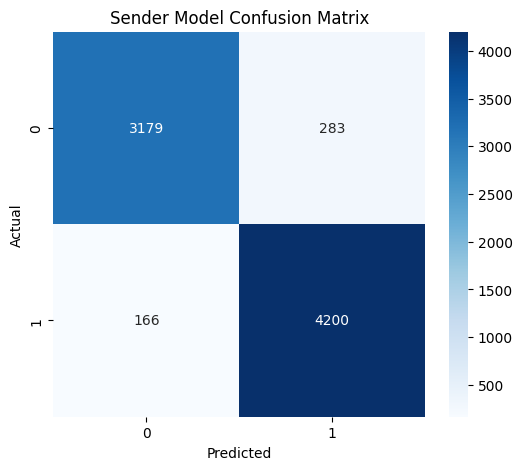

Sender Confusion Matrix Saved


In [ ]:
# =========================================================
# SAVE SENDER CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_sender_test,
    sender_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Sender Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

# SAVE IMAGE

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "sender_confusion_matrix.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Sender Confusion Matrix Saved")

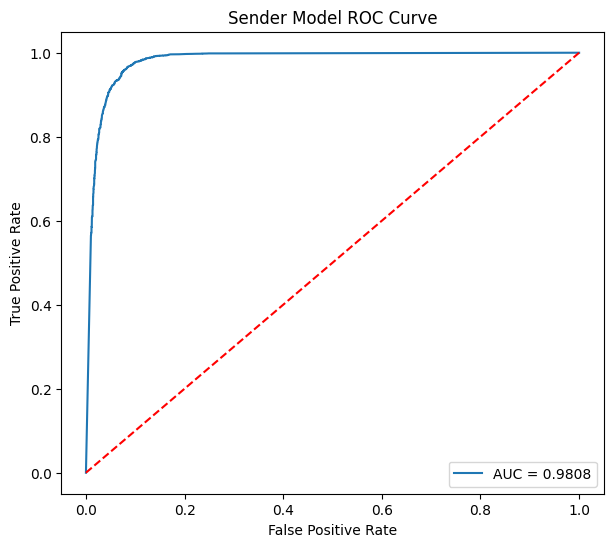

Sender ROC Curve Saved


In [ ]:
# =========================================================
# SAVE SENDER ROC CURVE
# =========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(

    y_sender_test,
    sender_probs
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_sender_test, sender_probs):.4f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Sender Model ROC Curve")

plt.legend()

# SAVE IMAGE

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "sender_roc_curve.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Sender ROC Curve Saved")

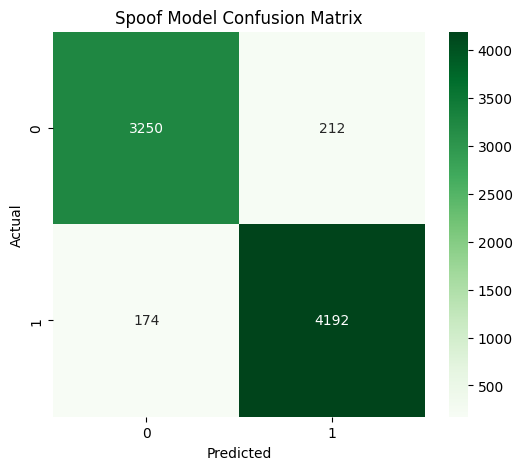

Spoof Confusion Matrix Saved


In [ ]:
# =========================================================
# SAVE SPOOF CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_spoof_test,
    spoof_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Spoof Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "spoof_confusion_matrix.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Spoof Confusion Matrix Saved")

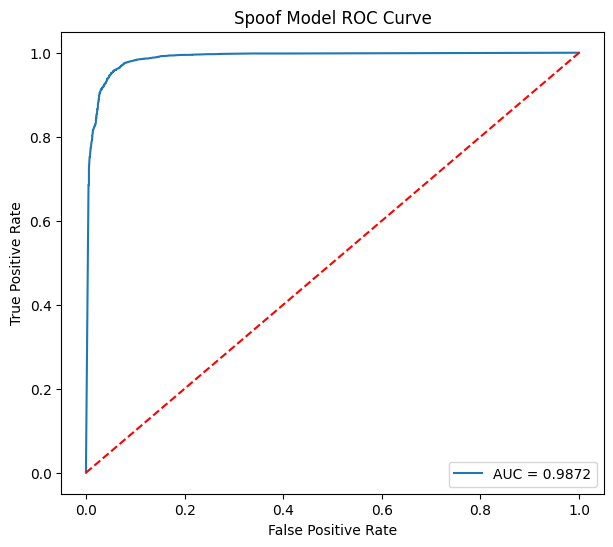

Spoof ROC Curve Saved


In [ ]:
# =========================================================
# SAVE SPOOF ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(

    y_spoof_test,
    spoof_probs
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_spoof_test, spoof_probs):.4f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Spoof Model ROC Curve")

plt.legend()

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "spoof_roc_curve.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Spoof ROC Curve Saved")

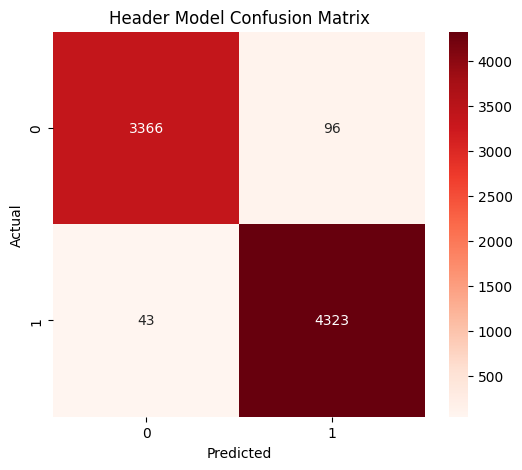

Header Confusion Matrix Saved


In [ ]:
# =========================================================
# SAVE HEADER CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_header_test,
    header_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Header Model Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "header_confusion_matrix.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Header Confusion Matrix Saved")

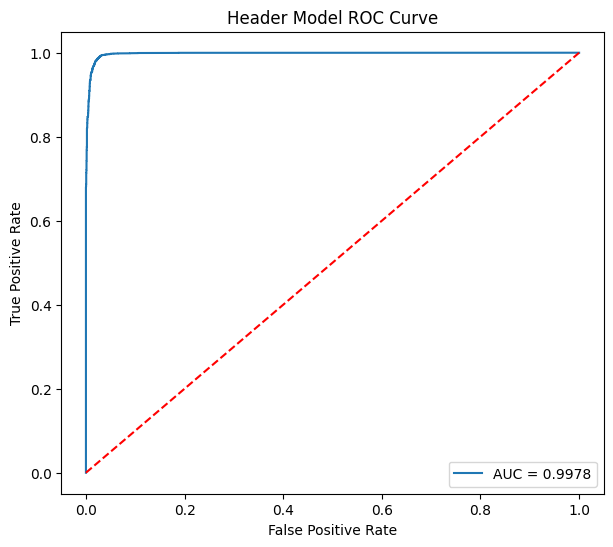

Header ROC Curve Saved


In [ ]:
# =========================================================
# SAVE HEADER ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(

    y_header_test,
    header_probs
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_header_test, header_probs):.4f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Header Model ROC Curve")

plt.legend()

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "header_roc_curve.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Header ROC Curve Saved")

CREATING COMBINED ROC CURVE


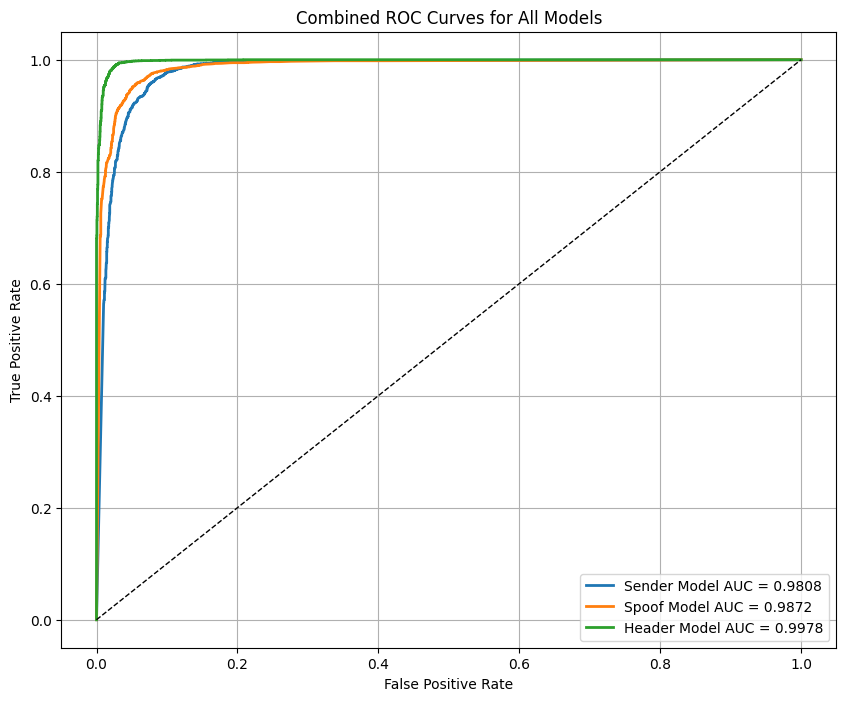


Combined ROC Curve Saved Successfully


In [ ]:
# =========================================================
# SAVE COMBINED ROC CURVE
# =========================================================

print("CREATING COMBINED ROC CURVE")

from sklearn.metrics import roc_curve, roc_auc_score

# ---------------------------------------------------------
# SENDER ROC
# ---------------------------------------------------------

sender_fpr, sender_tpr, _ = roc_curve(

    y_sender_test,
    sender_probs
)

sender_auc = roc_auc_score(

    y_sender_test,
    sender_probs
)

# ---------------------------------------------------------
# SPOOF ROC
# ---------------------------------------------------------

spoof_fpr, spoof_tpr, _ = roc_curve(

    y_spoof_test,
    spoof_probs
)

spoof_auc = roc_auc_score(

    y_spoof_test,
    spoof_probs
)

# ---------------------------------------------------------
# HEADER ROC
# ---------------------------------------------------------

header_fpr, header_tpr, _ = roc_curve(

    y_header_test,
    header_probs
)

header_auc = roc_auc_score(

    y_header_test,
    header_probs
)

# ---------------------------------------------------------
# PLOT ALL CURVES
# ---------------------------------------------------------

plt.figure(figsize=(10,8))

# Sender Model

plt.plot(

    sender_fpr,
    sender_tpr,
    linewidth=2,
    label=f"Sender Model AUC = {sender_auc:.4f}"
)

# Spoof Model

plt.plot(

    spoof_fpr,
    spoof_tpr,
    linewidth=2,
    label=f"Spoof Model AUC = {spoof_auc:.4f}"
)

# Header Model

plt.plot(

    header_fpr,
    header_tpr,
    linewidth=2,
    label=f"Header Model AUC = {header_auc:.4f}"
)

# Random Classifier Line

plt.plot(

    [0,1],
    [0,1],
    'k--',
    linewidth=1
)

# LABELS

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Combined ROC Curves for All Models")

plt.legend(loc="lower right")

plt.grid(True)

# ---------------------------------------------------------
# SAVE IMAGE
# ---------------------------------------------------------

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "combined_roc_curves_header.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nCombined ROC Curve Saved Successfully")

FINDING FEATURE IMPORTANCE

Top Important Features:

                       Feature  Importance
13            sender_frequency    0.502863
8   subject_special_char_count    0.110802
2       sender_uppercase_ratio    0.091854
3   sender_name_email_mismatch    0.071636
7    subject_exclamation_count    0.034046
16            domain_frequency    0.031336
18            is_free_provider    0.028852
15             subdomain_count    0.018335
10    subject_suspicious_score    0.017406
0          sender_email_length    0.016158
6      subject_uppercase_ratio    0.015153
1    sender_special_char_count    0.013405
12                 email_month    0.012785
9              subject_entropy    0.008553
14               domain_length    0.007970
5           subject_word_count    0.007812
4               subject_length    0.006493
11                  email_hour    0.004541
17              suspicious_tld    0.000000


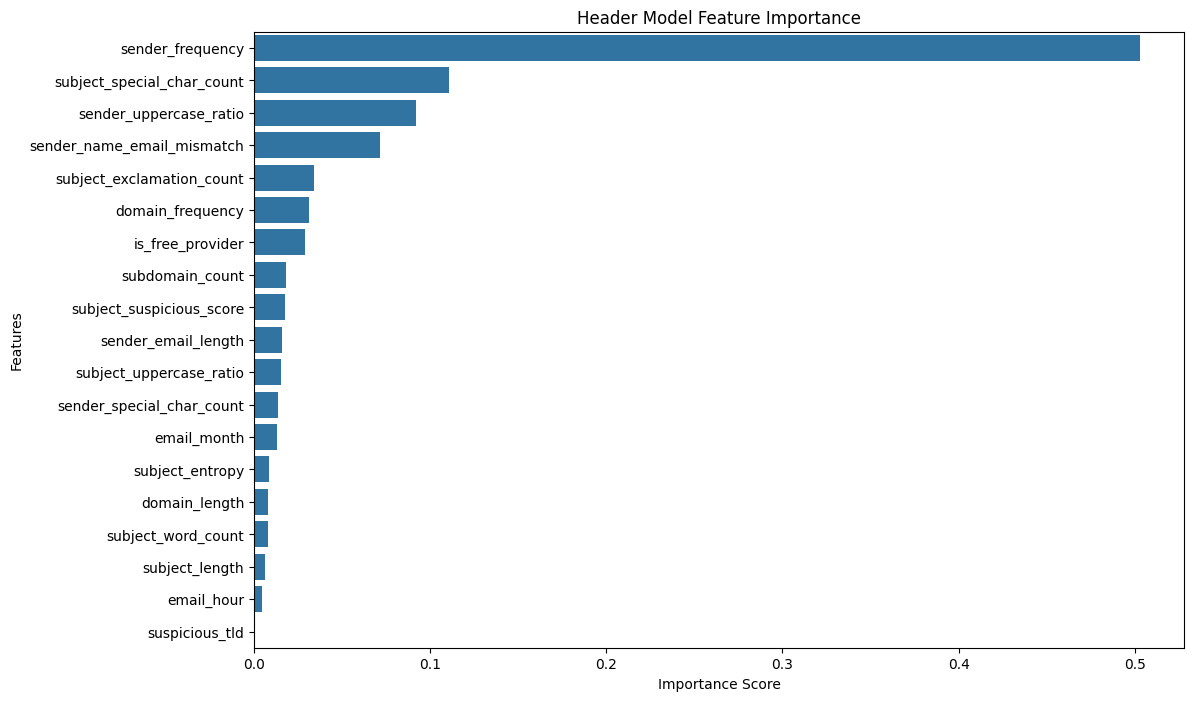


Feature Importance Saved Successfully


In [ ]:
# =========================================================
# FIND MOST IMPORTANT FEATURES
# =========================================================

print("FINDING FEATURE IMPORTANCE")

# ---------------------------------------------------------
# CREATE FEATURE IMPORTANCE DATAFRAME
# ---------------------------------------------------------

feature_importance = pd.DataFrame({

    'Feature': X_header.columns,

    'Importance': header_model.feature_importances_
})

# ---------------------------------------------------------
# SORT FEATURES
# ---------------------------------------------------------

feature_importance = feature_importance.sort_values(

    by='Importance',
    ascending=False
)

# ---------------------------------------------------------
# DISPLAY FEATURES
# ---------------------------------------------------------

print("\nTop Important Features:\n")

print(feature_importance)

# ---------------------------------------------------------
# SAVE FEATURE IMPORTANCE CSV
# ---------------------------------------------------------

feature_importance.to_csv(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "feature_importance.csv",

    index=False
)

# ---------------------------------------------------------
# PLOT FEATURE IMPORTANCE
# ---------------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(

    data=feature_importance,

    x='Importance',

    y='Feature'
)

plt.title("Header Model Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

# ---------------------------------------------------------
# SAVE IMAGE
# ---------------------------------------------------------

plt.savefig(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "feature_importance.png",

    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nFeature Importance Saved Successfully")

In [ ]:
# =========================================================
# SELECT MOST IMPORTANT FEATURES
# =========================================================

print("SELECTING MOST IMPORTANT FEATURES")

# ---------------------------------------------------------
# SELECT FEATURES WITH IMPORTANCE > 0.01
# ---------------------------------------------------------

important_features = feature_importance[

    feature_importance['Importance'] > 0.01
]

# ---------------------------------------------------------
# DISPLAY SELECTED FEATURES
# ---------------------------------------------------------

print("\nSelected Important Features:\n")

print(important_features)

# ---------------------------------------------------------
# EXTRACT FEATURE NAMES
# ---------------------------------------------------------

selected_feature_names = (
    important_features['Feature']
    .tolist()
)

print("\nFinal Selected Features:\n")

print(selected_feature_names)

# ---------------------------------------------------------
# CREATE NEW DATASET
# ---------------------------------------------------------

selected_feature_dataset = df_meta[
    selected_feature_names
]

# ADD LABEL COLUMN

selected_feature_dataset['label'] = y

# ---------------------------------------------------------
# SAVE CSV FILE
# ---------------------------------------------------------

selected_feature_dataset.to_csv(

    "/content/drive/MyDrive/"
    "Phishing_Project/reports/"
    "selected_important_features.csv",

    index=False
)

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\nSelected Feature Dataset Saved Successfully")

print("\nDataset Shape:")

print(selected_feature_dataset.shape)

In [ ]:
# =========================================================
# SELECT MOST IMPORTANT FEATURES
# =========================================================

print("SELECTING MOST IMPORTANT FEATURES")

# ---------------------------------------------------------
# SELECT FEATURES WITH IMPORTANCE > 0.01
# ---------------------------------------------------------

important_features = feature_importance[

    feature_importance['Importance'] > 0.01
]

# ---------------------------------------------------------
# DISPLAY SELECTED FEATURES
# ---------------------------------------------------------

print("\nSelected Important Features:\n")

print(important_features)

# ---------------------------------------------------------
# EXTRACT FEATURE NAMES
# ---------------------------------------------------------

selected_feature_names = (
    important_features['Feature']
    .tolist()
)

print("\nFinal Selected Features:\n")

print(selected_feature_names)

# ---------------------------------------------------------
# CREATE NEW DATASET
# ---------------------------------------------------------

selected_feature_dataset = df_meta[
    selected_feature_names
]

# ADD LABEL COLUMN

selected_feature_dataset['label'] = y

# ---------------------------------------------------------
# SAVE CSV FILE
# ---------------------------------------------------------

selected_feature_dataset.to_csv(

    "/content/drive/MyDrive/"
    "Phishing_Project/final_dataset/"
    "header_final_features.csv",

    index=False
)

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\nSelected Feature Dataset Saved Successfully")

print("\nDataset Shape:")

print(selected_feature_dataset.shape)

SELECTING MOST IMPORTANT FEATURES

Selected Important Features:

                       Feature  Importance
13            sender_frequency    0.502863
8   subject_special_char_count    0.110802
2       sender_uppercase_ratio    0.091854
3   sender_name_email_mismatch    0.071636
7    subject_exclamation_count    0.034046
16            domain_frequency    0.031336
18            is_free_provider    0.028852
15             subdomain_count    0.018335
10    subject_suspicious_score    0.017406
0          sender_email_length    0.016158
6      subject_uppercase_ratio    0.015153
1    sender_special_char_count    0.013405
12                 email_month    0.012785

Final Selected Features:

['sender_frequency', 'subject_special_char_count', 'sender_uppercase_ratio', 'sender_name_email_mismatch', 'subject_exclamation_count', 'domain_frequency', 'is_free_provider', 'subdomain_count', 'subject_suspicious_score', 'sender_email_length', 'subject_uppercase_ratio', 'sender_special_char_count', 'ema

/tmp/ipykernel_2392/78293195.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_feature_dataset['label'] = y



Selected Feature Dataset Saved Successfully

Dataset Shape:
(39139, 14)
